# FYP  Full Version  

## Main purpose

This notebook prepares and evaluates an integrated review dataset from **Airbnb, Booking.com, and Tripadvisor** for:

1. cross-platform data validation and benchmarking,
2. construction of the **Airbnb Data Development Index (ADDI)**,
3. four core empirical proxy tasks,
4. and a limited downstream ML signal check.

## workflow overview

1. Import packages and define helper functions  
2. Define file names and load raw datasets  
3. Introduce the raw data sources and their analytical roles  
4. Standardise Airbnb, Booking.com, and Tripadvisor data  
5. Align all platforms into a common schema and build the integrated dataset  
6. Perform validation, EDA, and anomaly diagnosis  
7. Use those diagnostics to justify cleaning and benchmark inclusion rules  
8. Construct the ADDI index as a **data-readiness step**  
9. Run the four core empirical tasks:  
   - Review-based Ranking Proxy  
   - Recommendation Proxy  
   - Trust & Safety Proxy  
   - Cross-platform Transfer / Generalization  
10. Run a limited downstream ML signal check under **entity_id strict split**  
11. Conclude with **data-first findings and recommendations**  
12. Export the final tables for the report or appendix  

## Important interpretation rules

`benchmark_input_df` is the **main benchmark dataset** used for the rigorous cross-platform tasks.  
`model_df` is a **narrower task-specific subset** created later only for the downstream text extension.

`city` / `location` fields are used mainly for **audit, EDA, anomaly diagnosis, and supplementary interpretation**.  
They are **not** treated as the strongest core comparative variable because geographic metadata granularity is inconsistent across the three platforms.


## Section 1. Import packages

This section loads the core Python libraries used throughout the notebook:

* `pandas` and `numpy` for data handling
* `matplotlib` for charts
* `sklearn` for text classification and evaluation



In [1]:
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import os

## Section 1A. Project paths and export folder

- `PROJECT_ROOT`: current working folder
- `DATA_DIR`: where raw CSV / source files are expected
- `EXPORT_DIR`: where generated tables and index outputs will be saved

In [2]:

PROJECT_ROOT = Path('.').resolve()
DATA_DIR = PROJECT_ROOT


EXPORT_DIR = PROJECT_ROOT / 'FYP_Exports'
REPORT_DIR = EXPORT_DIR / 'report_tables'
APPENDIX_DIR = EXPORT_DIR / 'appendix_tables'

for _p in [EXPORT_DIR, REPORT_DIR, APPENDIX_DIR]:
    _p.mkdir(parents=True, exist_ok=True)

# Export policy
EXPORT_INTERMEDIATE_TABLES = False
EXPORT_CURATED_FINAL_TABLES = True
EXPORT_MINIMAL_PACKAGE_ONLY = True
EXPORT_MANIFEST = False

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATA_DIR     =', DATA_DIR)
print('EXPORT_DIR   =', EXPORT_DIR)
print('REPORT_DIR   =', REPORT_DIR)
print('APPENDIX_DIR =', APPENDIX_DIR)
print('EXPORT_INTERMEDIATE_TABLES =', EXPORT_INTERMEDIATE_TABLES)
print('EXPORT_CURATED_FINAL_TABLES =', EXPORT_CURATED_FINAL_TABLES)
print('EXPORT_MINIMAL_PACKAGE_ONLY =', EXPORT_MINIMAL_PACKAGE_ONLY)
print('EXPORT_MANIFEST =', EXPORT_MANIFEST)


PROJECT_ROOT = C:\Users\Mo\Desktop\hkk\DataBase\FYP
DATA_DIR     = C:\Users\Mo\Desktop\hkk\DataBase\FYP
EXPORT_DIR   = C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Exports
REPORT_DIR   = C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Exports\report_tables
APPENDIX_DIR = C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Exports\appendix_tables
EXPORT_INTERMEDIATE_TABLES = False
EXPORT_CURATED_FINAL_TABLES = True
EXPORT_MINIMAL_PACKAGE_ONLY = True
EXPORT_MANIFEST = False


## Section 2. Helper functions for inspection and flexible file loading

In [3]:
def describe_df(df, name="DataFrame"):
    print(f"===== {name} =====")
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    print("Head:")
    display(df.head(3))


def find_first_existing(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None


def normalise_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    x = " ".join(x.split())
    return x


def safe_to_datetime(series):
    return pd.to_datetime(series, errors="coerce")


def word_count(x):
    if pd.isna(x) or str(x).strip() == "":
        return 0
    return len(str(x).split())


def char_count(x):
    if pd.isna(x):
        return 0
    return len(str(x))


def clean_city_name(series):
    s = series.copy().astype(str).str.strip().str.lower()
    s = s.str.replace(r"\s+", "_", regex=True)
    s = s.str.replace(r"[^a-z0-9_,\- ]", "", regex=True)
    s = s.str.replace(" ", "_", regex=False)

    invalid_patterns = [
        r"^$", r"^\?$", r"^-+$", r"^\*+$",
        r"^unknown$", r"^none$", r"^nan$", r"^n/a$", r"^na$"
    ]
    for pat in invalid_patterns:
        s = s.mask(s.str.match(pat, na=False), np.nan)

    s = s.mask(s.str.len() < 2, np.nan)
    return s


def extract_city_from_location_text(series):
    s = series.copy().astype(str).str.lower().str.strip()
    locality = s.str.extract(r"locality[_\s:,-]*([a-z0-9 _-]+)", expand=False)

    if locality is not None:
        locality = locality.str.replace(
            r"(_postal.*|,_postal.*|_region.*|,_region.*|_country.*|,_country.*)$",
            "",
            regex=True
        )
        locality = locality.str.replace(r"^_+|_+$", "", regex=True)
        locality = locality.str.replace(r"\s+", "_", regex=True)

    locality = clean_city_name(locality) if locality is not None else None
    return locality


def clean_entity_id(series):
    return pd.to_numeric(series, errors="coerce").astype("Int64")


def make_binary_high_rating(series, threshold=4.0):
    s = pd.to_numeric(series, errors="coerce")
    return (s >= threshold).astype(int)


def ensure_common_cols(df, common_cols):
    out = df.copy()
    for c in common_cols:
        if c not in out.columns:
            out[c] = np.nan
    return out[common_cols]


def read_csv_flexible(path, **kwargs):
    attempts = [
        {"encoding": "utf-8"},
        {"encoding": "utf-8-sig"},
        {"encoding": "cp1252"},
        {"encoding": "latin1"},
        {"encoding": "ISO-8859-1"},
    ]

    last_error = None
    for opt in attempts:
        try:
            return pd.read_csv(path, **opt, **kwargs)
        except Exception as e:
            last_error = e

    fallback_attempts = [
        {"encoding": "cp1252", "engine": "python", "on_bad_lines": "skip"},
        {"encoding": "latin1", "engine": "python", "on_bad_lines": "skip"},
        {"encoding": "ISO-8859-1", "engine": "python", "on_bad_lines": "skip"},
    ]

    for opt in fallback_attempts:
        try:
            return pd.read_csv(path, **opt, **kwargs)
        except Exception as e:
            last_error = e

    raise last_error


def read_tripadvisor_review_source(path):
    """
    Load Tripadvisor review-level raw data from:
    - review.txt.zip (preferred original JSON lines source)
    - review.txt / .json / .jsonl
    - csv fallback
    """
    path = Path(path)
    suffixes = {s.lower() for s in path.suffixes}

    def _flatten_trip_record(obj):
        ratings = obj.get("ratings", {}) if isinstance(obj.get("ratings", {}), dict) else {}
        author = obj.get("author", {}) if isinstance(obj.get("author", {}), dict) else {}

        return {
            "offering_id": obj.get("offering_id"),
            "review_id": obj.get("review_id"),
            "title": obj.get("title"),
            "text": obj.get("text"),
            "author_username": author.get("username"),
            "rating_value": ratings.get("overall"),
            "review_date": obj.get("published_date") or obj.get("date") or obj.get("review_date"),
            "date_stayed": obj.get("date_stayed"),
            "language": obj.get("language") or obj.get("lang"),
        }

    if ".zip" in suffixes:
        rows = []
        with zipfile.ZipFile(path, "r") as z:
            text_names = [
                n for n in z.namelist()
                if n.lower().endswith((".txt", ".jsonl", ".json"))
            ]
            if not text_names:
                raise FileNotFoundError(f"No .txt/.jsonl/.json file found inside {path}")
            target_name = text_names[0]
            with z.open(target_name) as f:
                for raw_line in f:
                    line = raw_line.decode("utf-8").strip()
                    if not line:
                        continue
                    rows.append(_flatten_trip_record(json.loads(line)))
        return pd.DataFrame(rows)

    if path.suffix.lower() in {".txt", ".jsonl", ".json"}:
        rows = []
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rows.append(_flatten_trip_record(json.loads(line)))
        return pd.DataFrame(rows)

    return read_csv_flexible(path)

from sklearn.model_selection import GroupShuffleSplit

def normalise_text_for_dup(s):
    if pd.isna(s):
        return ""
    s = str(s).lower().strip()
    s = re.sub(r"<[^>]+>", " ", s)
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^a-z0-9\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def strict_entity_split(df, entity_col="entity_id", test_size=0.20, random_state=42):
    tmp = df.copy()
    if entity_col not in tmp.columns:
        raise KeyError(f"{entity_col} not found for strict split.")
    tmp = tmp[tmp[entity_col].notna()].copy()
    tmp[entity_col] = tmp[entity_col].astype(str)

    if tmp[entity_col].nunique() < 2:
        raise ValueError("Not enough unique entities for entity-strict split.")

    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(tmp, groups=tmp[entity_col]))
    train_df = tmp.iloc[train_idx].copy()
    test_df = tmp.iloc[test_idx].copy()
    return train_df, test_df

def compute_overlap_summary(train_df, test_df, text_col="review_text", entity_col="entity_id", split_type="entity_id_strict"):
    train_text_set = set(train_df[text_col].dropna().astype(str))
    test_text_set = set(test_df[text_col].dropna().astype(str))
    train_entity_set = set(train_df[entity_col].dropna().astype(str))
    test_entity_set = set(test_df[entity_col].dropna().astype(str))

    return {
        "split_type": split_type,
        "entity_overlap_count": len(train_entity_set.intersection(test_entity_set)),
        "exact_text_overlap_count": len(train_text_set.intersection(test_text_set)),
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "n_train_entities": train_df[entity_col].nunique(dropna=True),
        "n_test_entities": test_df[entity_col].nunique(dropna=True),
    }


## Section 3. Rating normalisation helpers

Different platforms ratings on different scales. It defines the ratings into a common **0–5 scale**, which is needed for fair comparison and downstream modelling.

In [4]:
def normalise_airbnb_rating_to_5(series):
    s = pd.to_numeric(series, errors="coerce")

    if s.dropna().empty:
        return s

    max_val = s.dropna().max()


    if max_val > 5 and max_val <= 100:
        return s / 20.0

    return s


def normalise_booking_rating_to_5(series):
    s = pd.to_numeric(series, errors="coerce")

    if s.dropna().empty:
        return s

    max_val = s.dropna().max()


    if max_val > 5 and max_val <= 10:
        return s / 2.0


    if max_val > 10 and max_val <= 100:
        return s / 20.0

    return s


def normalise_tripadvisor_rating_to_5(series):
    s = pd.to_numeric(series, errors="coerce")

    if s.dropna().empty:
        return s

    out = s.copy()
    out = pd.Series(out, index=s.index)
    out.loc[(s > 5) & (s <= 10)] = s[(s > 5) & (s <= 10)] / 2.0
    out.loc[(s > 10) & (s <= 100)] = s[(s > 10) & (s <= 100)] / 20.0
    out = pd.to_numeric(out, errors="coerce")
    out = out.where(out.between(1, 5, inclusive="both"))
    return out

    if s.dropna().empty:
        return s


    return s

## Section 4. File mapping and dataset definitions

In [5]:

AIRBNB_REVIEW_FILES = {
    "hong_kong": "Airbnb reviews hk.csv",
    "london": "Airbnb reviews london.csv",
    "istanbul": "Airbnb reviews istanbul.csv"
}

AIRBNB_LISTING_FILES = {
    "hong_kong": "Airbnb_listings_hk.csv",
    "london": "Airbnb_listings_london.csv",
    "istanbul": "Airbnb_listings_istanbul.csv"
}

BOOKING_TRAIN_CANDIDATES = [
    "Booking.com_train.csv",
    "Booking.com_train.zip",
]
BOOKING_TRAIN = next(
    (fname for fname in BOOKING_TRAIN_CANDIDATES if (DATA_DIR / fname).exists()),
    BOOKING_TRAIN_CANDIDATES[0]
)

BOOKING_VAL = "booking.com_val.csv"
BOOKING_META = "book.com_hotels.csv"

TRIP_REVIEW_PART_FILES = [f"review_fyp_part_{i}.csv" for i in range(1, 10)]
AVAILABLE_TRIP_REVIEW_PART_FILES = [
    fname for fname in TRIP_REVIEW_PART_FILES if (DATA_DIR / fname).exists()
]

TRIP_REVIEW_CANDIDATES = [
    "review.txt.zip",
    "review.txt",
    "review.jsonl",
    "review_fyp_merged.csv",
]

if len(AVAILABLE_TRIP_REVIEW_PART_FILES) == 9:
    TRIP_REVIEW_MODE = "multipart_csv"
    TRIP_REVIEW_INPUT = AVAILABLE_TRIP_REVIEW_PART_FILES
    TRIP_REVIEW_SOURCE_LABEL = "review_fyp_part_1_to_9.csv"
else:
    TRIP_REVIEW_MODE = "single_source"
    TRIP_REVIEW_INPUT = next(
        (fname for fname in TRIP_REVIEW_CANDIDATES if (DATA_DIR / fname).exists()),
        TRIP_REVIEW_CANDIDATES[0]
    )
    TRIP_REVIEW_SOURCE_LABEL = str(TRIP_REVIEW_INPUT)

TRIP_META = "tripadviser.csv"
TRIP_SUMMARY = "hotel_summary_clean.csv"

print("Booking train source selected:", BOOKING_TRAIN)
print("Tripadvisor review mode:", TRIP_REVIEW_MODE)
print("Tripadvisor review source selected:", TRIP_REVIEW_INPUT)


Booking train source selected: Booking.com_train.csv
Tripadvisor review mode: multipart_csv
Tripadvisor review source selected: ['review_fyp_part_1.csv', 'review_fyp_part_2.csv', 'review_fyp_part_3.csv', 'review_fyp_part_4.csv', 'review_fyp_part_5.csv', 'review_fyp_part_6.csv', 'review_fyp_part_7.csv', 'review_fyp_part_8.csv', 'review_fyp_part_9.csv']


## Section 4A. Data provenance, source registry, and audit principle

A cross-platform benchmark is only credible if each observation can be traced back to its original source. For that reason, it follows four audit principles throughout:

1. **Source transparency**: every platform dataset is linked to its original file name.
2. **Schema transparency**: each source is assigned a clear analytical role such as review-level text, listing metadata, hotel metadata, or summary metadata.
3. **Transformation transparency**: any cleaning, alignment, normalisation, or filtering step must be documented and justified.
4. **Retention transparency**: rows are only dropped for explicit methodological reasons, not to artificially improve performance.

In [6]:

source_registry_rows = []

for city, fname in AIRBNB_REVIEW_FILES.items():
    source_registry_rows.append({
        "platform": "airbnb",
        "source_group": "review",
        "source_variable": f"AIRBNB_REVIEW_FILES[{city!r}]",
        "file_name": fname,
        "city_scope": city,
        "unit_of_observation": "review",
        "benchmark_role": "review text source"
    })

for city, fname in AIRBNB_LISTING_FILES.items():
    source_registry_rows.append({
        "platform": "airbnb",
        "source_group": "listing_meta",
        "source_variable": f"AIRBNB_LISTING_FILES[{city!r}]",
        "file_name": fname,
        "city_scope": city,
        "unit_of_observation": "listing/entity",
        "benchmark_role": "listing metadata enrichment"
    })

source_registry_rows.extend([
    {
        "platform": "booking",
        "source_group": "review",
        "source_variable": "BOOKING_TRAIN",
        "file_name": BOOKING_TRAIN,
        "city_scope": "mixed / not explicit",
        "unit_of_observation": "review",
        "benchmark_role": "review text source"
    },
    {
        "platform": "booking",
        "source_group": "review",
        "source_variable": "BOOKING_VAL",
        "file_name": BOOKING_VAL,
        "city_scope": "mixed / not explicit",
        "unit_of_observation": "review",
        "benchmark_role": "review text source"
    },
    {
        "platform": "booking",
        "source_group": "entity_meta",
        "source_variable": "BOOKING_META",
        "file_name": BOOKING_META,
        "city_scope": "mixed / not explicit",
        "unit_of_observation": "entity",
        "benchmark_role": "supplementary metadata only"
    },
])

if TRIP_REVIEW_MODE == "multipart_csv":
    for fname in AVAILABLE_TRIP_REVIEW_PART_FILES:
        source_registry_rows.append({
            "platform": "tripadvisor",
            "source_group": "review",
            "source_variable": "TRIP_REVIEW_INPUT",
            "file_name": fname,
            "city_scope": "mixed / not explicit",
            "unit_of_observation": "review",
            "benchmark_role": "review text source (multipart raw review file)"
        })
else:
    source_registry_rows.append({
        "platform": "tripadvisor",
        "source_group": "review",
        "source_variable": "TRIP_REVIEW_INPUT",
        "file_name": str(TRIP_REVIEW_INPUT),
        "city_scope": "mixed / not explicit",
        "unit_of_observation": "review",
        "benchmark_role": "review text source"
    })

source_registry_rows.extend([
    {
        "platform": "tripadvisor",
        "source_group": "entity_meta",
        "source_variable": "TRIP_META",
        "file_name": TRIP_META,
        "city_scope": "mixed / not explicit",
        "unit_of_observation": "entity",
        "benchmark_role": "metadata enrichment"
    },
    {
        "platform": "tripadvisor",
        "source_group": "summary_meta",
        "source_variable": "TRIP_SUMMARY",
        "file_name": TRIP_SUMMARY,
        "city_scope": "mixed / not explicit",
        "unit_of_observation": "entity",
        "benchmark_role": "rating / review-count enrichment"
    }
])

source_registry_df = pd.DataFrame(source_registry_rows)
print("Source registry prepared. Final curated export happens in the last section.")
display(source_registry_df)


Source registry prepared. Final curated export happens in the last section.


,platform,source_group,source_variable,file_name,city_scope,unit_of_observation,benchmark_role
0,airbnb,review,AIRBNB_REVIEW_FILES['hong_kong'],Airbnb reviews hk.csv,hong_kong,review,review text source
1,airbnb,review,AIRBNB_REVIEW_FILES['london'],Airbnb reviews london.csv,london,review,review text source
2,airbnb,review,AIRBNB_REVIEW_FILES['istanbul'],Airbnb reviews istanbul.csv,istanbul,review,review text source
3,airbnb,listing_meta,AIRBNB_LISTING_FILES['hong_kong'],Airbnb_listings_hk.csv,hong_kong,listing/entity,listing metadata enrichment
4,airbnb,listing_meta,AIRBNB_LISTING_FILES['london'],Airbnb_listings_london.csv,london,listing/entity,listing metadata enrichment
5,airbnb,listing_meta,AIRBNB_LISTING_FILES['istanbul'],Airbnb_listings_istanbul.csv,istanbul,listing/entity,listing metadata enrichment
6,booking,review,BOOKING_TRAIN,Booking.com_train.csv,mixed / not explicit,review,review text source
7,booking,review,BOOKING_VAL,booking.com_val.csv,mixed / not explicit,review,review text source
8,booking,entity_meta,BOOKING_META,book.com_hotels.csv,mixed / not explicit,entity,supplementary metadata only
9,tripadvisor,review,TRIP_REVIEW_INPUT,review_fyp_part_1.csv,mixed / not explicit,review,review text source (multipart raw review file)


## Section 5. Load raw source data


In [7]:
airbnb_reviews_raw = {
    city: read_csv_flexible(fname)
    for city, fname in AIRBNB_REVIEW_FILES.items()
}

airbnb_listings_raw = {
    city: read_csv_flexible(fname)
    for city, fname in AIRBNB_LISTING_FILES.items()
}

booking_train_raw = read_csv_flexible(BOOKING_TRAIN)
booking_val_raw = read_csv_flexible(BOOKING_VAL)
booking_meta_raw = read_csv_flexible(BOOKING_META) if (DATA_DIR / BOOKING_META).exists() else pd.DataFrame()

if TRIP_REVIEW_MODE == "multipart_csv":
    trip_review_parts_raw = [read_csv_flexible(fname) for fname in AVAILABLE_TRIP_REVIEW_PART_FILES]
    trip_review_raw = pd.concat(trip_review_parts_raw, ignore_index=True)
else:
    trip_review_parts_raw = None
    trip_review_raw = read_tripadvisor_review_source(TRIP_REVIEW_INPUT)

trip_meta_raw = read_csv_flexible(TRIP_META) if (DATA_DIR / TRIP_META).exists() else pd.DataFrame()
trip_summary_raw = read_csv_flexible(TRIP_SUMMARY) if (DATA_DIR / TRIP_SUMMARY).exists() else pd.DataFrame()

print("Raw data loaded successfully.")
print("Airbnb review files:", {k: v.shape for k, v in airbnb_reviews_raw.items()})
print("Airbnb listing files:", {k: v.shape for k, v in airbnb_listings_raw.items()})
print("Booking train:", booking_train_raw.shape)
print("Booking val:", booking_val_raw.shape)
print("Booking meta:", booking_meta_raw.shape)
print("Trip review raw:", trip_review_raw.shape)
print("Trip meta:", trip_meta_raw.shape)
print("Trip summary:", trip_summary_raw.shape)
if trip_summary_raw.empty:
    print("[INFO] hotel_summary_clean.csv not found -> Tripadvisor summary enrichment will be skipped automatically.")


C:\Users\Mo\AppData\Local\Temp\ipykernel_36692\579092401.py:104: DtypeWarning: Columns (0,1,3,27,30,32,35,37,40,41,42,43,44,45,46,47,48,49,50,52,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, **opt, **kwargs)
C:\Users\Mo\AppData\Local\Temp\ipykernel_36692\579092401.py:104: DtypeWarning: Columns (0,1,2,3,11,12,13,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, **opt, **kwargs)
C:\Users\Mo\AppData\Local\Temp\ipykernel_36692\579092401.py:104: DtypeWarning: Columns (0,1,16,17,18,19,20,21,22,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, **opt, **kwargs)
C:\Users\Mo\AppData\Local\Temp\ipykernel_36692\579092401.py:104: DtypeWarning: Columns (0,2,48,53,60,61,65,68,69,70,71,75,76,77,78,79,80,81

Raw data loaded successfully.
Airbnb review files: {'hong_kong': (84435, 56), 'london': (1048575, 54), 'istanbul': (534856, 30)}
Airbnb listing files: {'hong_kong': (6803, 105), 'london': (97024, 105), 'istanbul': (30051, 79)}
Booking train: (1628989, 17)
Booking val: (203787, 17)
Booking meta: (25, 4)
Trip review raw: (878561, 17)
Trip meta: (4333, 9)
Trip summary: (3945, 4)



## Section 5A. Raw data inventory and source verification


In [8]:
AIRBNB_REVIEW_FILES = {
    "hong_kong": "Airbnb reviews hk.csv",
    "london": "Airbnb reviews london.csv",
    "istanbul": "Airbnb reviews istanbul.csv"
}

AIRBNB_LISTING_FILES = {
    "hong_kong": "Airbnb_listings_hk.csv",
    "london": "Airbnb_listings_london.csv",
    "istanbul": "Airbnb_listings_istanbul.csv"
}

BOOKING_TRAIN = "Booking.com_train.csv"
BOOKING_VAL = "booking.com_val.csv"
BOOKING_META = "book.com_hotels.csv"

TRIP_REVIEW = "review_fyp_merged.csv"
TRIP_META = "tripadviser.csv"
TRIP_SUMMARY = "hotel_summary_clean.csv"

In [9]:
# Raw source inventory for strict audit trail
raw_inventory_rows = []

for city, df_ in airbnb_reviews_raw.items():
    raw_inventory_rows.append({
        "platform": "airbnb",
        "source_group": "review",
        "source_name": AIRBNB_REVIEW_FILES[city],
        "city_scope": city,
        "n_rows_raw": len(df_),
        "n_cols_raw": len(df_.columns),
        "columns_raw": ", ".join(df_.columns.astype(str))
    })

for city, df_ in airbnb_listings_raw.items():
    raw_inventory_rows.append({
        "platform": "airbnb",
        "source_group": "listing_meta",
        "source_name": AIRBNB_LISTING_FILES[city],
        "city_scope": city,
        "n_rows_raw": len(df_),
        "n_cols_raw": len(df_.columns),
        "columns_raw": ", ".join(df_.columns.astype(str))
    })

for src_name, df_ in [
    (BOOKING_TRAIN, booking_train_raw),
    (BOOKING_VAL, booking_val_raw),
    (BOOKING_META, booking_meta_raw),
    (TRIP_REVIEW, trip_review_raw),
    (TRIP_META, trip_meta_raw),
    (TRIP_SUMMARY, trip_summary_raw),
]:
    platform_name = (
        "booking" if src_name in [BOOKING_TRAIN, BOOKING_VAL, BOOKING_META]
        else "tripadvisor"
    )
    source_group = (
        "review" if src_name in [BOOKING_TRAIN, BOOKING_VAL, TRIP_REVIEW]
        else "entity_meta"
    )
    if src_name == TRIP_SUMMARY:
        source_group = "summary_meta"

    raw_inventory_rows.append({
        "platform": platform_name,
        "source_group": source_group,
        "source_name": src_name,
        "city_scope": "mixed / not explicit",
        "n_rows_raw": len(df_),
        "n_cols_raw": len(df_.columns),
        "columns_raw": ", ".join(df_.columns.astype(str))
    })

raw_inventory_df = pd.DataFrame(raw_inventory_rows)
print(raw_inventory_df[["platform", "source_group", "source_name", "city_scope", "n_rows_raw", "n_cols_raw"]])
print("Raw inventory prepared. Final curated export happens in the last section.")


       platform  source_group                   source_name  \
0        airbnb        review         Airbnb reviews hk.csv   
1        airbnb        review     Airbnb reviews london.csv   
2        airbnb        review   Airbnb reviews istanbul.csv   
3        airbnb  listing_meta        Airbnb_listings_hk.csv   
4        airbnb  listing_meta    Airbnb_listings_london.csv   
5        airbnb  listing_meta  Airbnb_listings_istanbul.csv   
6       booking        review         Booking.com_train.csv   
7       booking        review           booking.com_val.csv   
8       booking   entity_meta           book.com_hotels.csv   
9   tripadvisor        review         review_fyp_merged.csv   
10  tripadvisor   entity_meta               tripadviser.csv   
11  tripadvisor  summary_meta       hotel_summary_clean.csv   

              city_scope  n_rows_raw  n_cols_raw  
0              hong_kong       84435          56  
1                 london     1048575          54  
2               istanbul   

## Section 5B. Raw Data Overview and platform-specific interpretation

Because Airbnb, Booking.com, and Tripadvisor do not provide equally consistent city-level metadata, **location / city fields are treated as supplementary variables rather than the strongest core benchmark variables**.


In [10]:
raw_source_overview_rows = [
    {
        "platform": "airbnb",
        "core_raw_sources": "city-level review files + city-level listings files",
        "main_review_unit": "review",
        "main_entity_unit": "listing",
        "primary_rating_signal": "listing review_scores_rating linked by listing_id",
        "location_interpretation": "city / listing metadata relatively clear",
        "core_use_decision": "use as core source"
    },
    {
        "platform": "booking",
        "core_raw_sources": f"{BOOKING_TRAIN} + {BOOKING_VAL}",
        "main_review_unit": "review",
        "main_entity_unit": "accommodation",
        "primary_rating_signal": "review_score on 3-10 scale, later normalised to 0-5",
        "location_interpretation": "country + location flags, not a strongly comparable city field",
        "core_use_decision": "use as core source"
    },
    {
        "platform": "tripadvisor",
        "core_raw_sources": TRIP_REVIEW_SOURCE_LABEL,
        "main_review_unit": "review",
        "main_entity_unit": "offering / hotel",
        "primary_rating_signal": "rating_overall / review-level score on 0-5 scale",
        "location_interpretation": "locality more useful than region; author_location is reviewer-side metadata",
        "core_use_decision": "use as core source"
    },
    {
        "platform": "airbnb_intermediate",
        "core_raw_sources": "Airbnb _common_reviews.csv",
        "main_review_unit": "review",
        "main_entity_unit": "listing",
        "primary_rating_signal": "unstable / intermediate",
        "location_interpretation": "not used",
        "core_use_decision": "exclude from core pipeline"
    }
]

raw_source_overview_df = pd.DataFrame(raw_source_overview_rows)
display(raw_source_overview_df)


,platform,core_raw_sources,main_review_unit,main_entity_unit,primary_rating_signal,location_interpretation,core_use_decision
0,airbnb,city-level review files + city-level listings ...,review,listing,listing review_scores_rating linked by listing_id,city / listing metadata relatively clear,use as core source
1,booking,Booking.com_train.csv + booking.com_val.csv,review,accommodation,"review_score on 3-10 scale, later normalised t...","country + location flags, not a strongly compa...",use as core source
2,tripadvisor,review_fyp_part_1_to_9.csv,review,offering / hotel,rating_overall / review-level score on 0-5 scale,locality more useful than region; author_locat...,use as core source
3,airbnb_intermediate,Airbnb _common_reviews.csv,review,listing,unstable / intermediate,not used,exclude from core pipeline


# Part A. Airbnb preprocessing


## Section 6. Standardise Airbnb review records


In [11]:
def standardise_airbnb_reviews(review_df, city):
    df = review_df.copy()
    cols = set(df.columns)

    review_text_col = find_first_existing(cols, [
        "comments", "review_text", "text", "review", "comments_en"
    ])
    date_col = find_first_existing(cols, [
        "date", "review_date", "created_at"
    ])
    listing_id_col = find_first_existing(cols, [
        "listing_id", "property_id", "room_id"
    ])
    reviewer_col = find_first_existing(cols, [
        "reviewer_name", "reviewer", "user_name", "guest_name"
    ])

    out = pd.DataFrame({
        "platform": "airbnb",
        "city": city,
        "entity_id": clean_entity_id(df[listing_id_col]) if listing_id_col else np.nan,
        "entity_name": np.nan,
        "review_text": df[review_text_col].fillna("").astype(str).map(normalise_text) if review_text_col else "",
        "rating_raw": np.nan,
        "rating_norm": np.nan,
        "review_date": safe_to_datetime(df[date_col]) if date_col else pd.NaT,
        "reviewer_name": df[reviewer_col] if reviewer_col else np.nan,
        "source_file": AIRBNB_REVIEW_FILES[city]
    })

    out["review_word_count"] = out["review_text"].map(word_count)
    out["review_char_count"] = out["review_text"].map(char_count)
    out["is_long_review"] = (out["review_word_count"] >= 50).astype(int)

    return out

## Section 7. Standardise Airbnb listing metadata


In [12]:
def standardise_airbnb_listings(listing_df, city):
    df = listing_df.copy()
    cols = set(df.columns)

    id_col = find_first_existing(cols, ["id", "listing_id"])
    name_col = find_first_existing(cols, ["name", "listing_name", "title"])
    rating_col = find_first_existing(cols, [
        "review_scores_rating", "rating", "overall_rating", "review_score"
    ])
    reviews_count_col = find_first_existing(cols, [
        "number_of_reviews", "reviews_count", "review_count"
    ])

    rating_raw = pd.to_numeric(df[rating_col], errors="coerce") if rating_col else np.nan
    rating_norm = normalise_airbnb_rating_to_5(rating_raw) if rating_col else np.nan

    out = pd.DataFrame({
        "platform": "airbnb",
        "city": city,
        "entity_id": clean_entity_id(df[id_col]) if id_col else pd.Series(np.arange(len(df)).astype(str)),
        "entity_name": df[name_col] if name_col else np.nan,
        "listing_rating_raw": rating_raw,
        "listing_rating_norm": rating_norm,
        "listing_review_count": pd.to_numeric(df[reviews_count_col], errors="coerce") if reviews_count_col else np.nan,
        "source_file": AIRBNB_LISTING_FILES[city]
    })

    return out

## Section 8. Build the final Airbnb dataset


In [13]:
airbnb_reviews_std = pd.concat(
    [standardise_airbnb_reviews(df, city) for city, df in airbnb_reviews_raw.items()],
    ignore_index=True
)

airbnb_listings_std = pd.concat(
    [standardise_airbnb_listings(df, city) for city, df in airbnb_listings_raw.items()],
    ignore_index=True
)

airbnb_final = airbnb_reviews_std.merge(
    airbnb_listings_std[
        ["entity_id", "entity_name", "listing_rating_raw", "listing_rating_norm", "listing_review_count"]
    ],
    on="entity_id",
    how="left",
    suffixes=("", "_listing")
)

airbnb_final["rating_raw"] = airbnb_final["rating_raw"].fillna(airbnb_final["listing_rating_raw"])
airbnb_final["rating_norm"] = airbnb_final["rating_norm"].fillna(airbnb_final["listing_rating_norm"])

airbnb_final["rating_norm"] = pd.to_numeric(airbnb_final["rating_norm"], errors="coerce")
airbnb_final.loc[
    ~airbnb_final["rating_norm"].between(0, 5, inclusive="both"),
    "rating_norm"
] = np.nan
airbnb_final.loc[airbnb_final["rating_norm"] <= 0, "rating_norm"] = np.nan

airbnb_final["high_rating"] = make_binary_high_rating(airbnb_final["rating_norm"], threshold=4.0)

describe_df(airbnb_final, "Airbnb Final")
print("Matched Airbnb listing names:", airbnb_final["entity_name"].notna().sum())
print(airbnb_final["rating_norm"].describe())

C:\Users\Mo\AppData\Local\Temp\ipykernel_36692\579092401.py:26: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  return pd.to_datetime(series, errors="coerce")
C:\Users\Mo\AppData\Local\Temp\ipykernel_36692\579092401.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(series, errors="coerce")


===== Airbnb Final =====
Shape: (1745445, 18)
Columns:
['platform', 'city', 'entity_id', 'entity_name', 'review_text', 'rating_raw', 'rating_norm', 'review_date', 'reviewer_name', 'source_file', 'review_word_count', 'review_char_count', 'is_long_review', 'entity_name_listing', 'listing_rating_raw', 'listing_rating_norm', 'listing_review_count', 'high_rating']
Head:


,platform,city,entity_id,entity_name,review_text,rating_raw,rating_norm,review_date,reviewer_name,source_file,review_word_count,review_char_count,is_long_review,entity_name_listing,listing_rating_raw,listing_rating_norm,listing_review_count,high_rating
0,airbnb,hong_kong,103760,NaN,We had a great experience staying in this apar...,4.47,4.47,2011-06-19,Kathleen,Airbnb reviews hk.csv,167,945,1,Central Centre 5 min walk to/from Central MTR,4.47,4.47,316.0,1
1,airbnb,hong_kong,103760,NaN,This apartment is in a fabulous location - wal...,4.47,4.47,2011-07-04,Lynne,Airbnb reviews hk.csv,46,262,0,Central Centre 5 min walk to/from Central MTR,4.47,4.47,316.0,1
2,airbnb,hong_kong,103760,NaN,Pretty good little apartment. Just a really gr...,4.47,4.47,2011-07-08,Camille,Airbnb reviews hk.csv,35,191,0,Central Centre 5 min walk to/from Central MTR,4.47,4.47,316.0,1


Matched Airbnb listing names: 0
count    1.391743e+06
mean     4.744098e+00
std      3.235572e-01
min      5.000000e-02
25%      4.670000e+00
50%      4.810000e+00
75%      4.900000e+00
max      5.000000e+00
Name: rating_norm, dtype: float64


# Part B. Booking.com preprocessing


## Section 9. Standardise Booking.com review records


In [14]:
def standardise_booking_reviews(df, source_file):
    data = df.copy()
    cols = set(data.columns)

    text_col = find_first_existing(cols, [
        "review_text", "text", "review", "review_positive"
    ])
    neg_col = find_first_existing(cols, [
        "review_negative", "negative_review"
    ])
    rating_col = find_first_existing(cols, [
        "review_score", "rating", "score"
    ])
    date_col = find_first_existing(cols, [
        "date", "review_date"
    ])
    id_col = find_first_existing(cols, [
        "accommodation_id", "hotel_id", "entity_id", "id"
    ])
    name_col = find_first_existing(cols, [
        "hotel_name", "accommodation_name", "name", "title"
    ])
    city_col = find_first_existing(cols, [
        "city", "hotel_city", "accommodation_city"
    ])
    reviewer_col = find_first_existing(cols, [
        "reviewer_name", "user_name", "guest_name"
    ])

    positive_text = data[text_col].fillna("").astype(str) if text_col else ""
    negative_text = data[neg_col].fillna("").astype(str) if neg_col else ""

    if isinstance(positive_text, str):
        combined_text = positive_text
    else:
        combined_text = (positive_text + " " + negative_text).str.strip().map(normalise_text)

    rating_raw = pd.to_numeric(data[rating_col], errors="coerce") if rating_col else np.nan
    rating_norm = normalise_booking_rating_to_5(rating_raw) if rating_col else np.nan

    out = pd.DataFrame({
        "platform": "booking",
        "city": clean_city_name(data[city_col]) if city_col else np.nan,
        "entity_id": clean_entity_id(data[id_col]) if id_col else pd.Series(np.arange(len(data)).astype(str)),
        "entity_name": data[name_col] if name_col else np.nan,
        "review_text": combined_text,
        "rating_raw": rating_raw,
        "rating_norm": rating_norm,
        "review_date": safe_to_datetime(data[date_col]) if date_col else pd.NaT,
        "reviewer_name": data[reviewer_col] if reviewer_col else np.nan,
        "source_file": source_file
    })

    out["review_word_count"] = out["review_text"].map(word_count)
    out["review_char_count"] = out["review_text"].map(char_count)
    out["is_long_review"] = (out["review_word_count"] >= 50).astype(int)
    out["high_rating"] = make_binary_high_rating(out["rating_norm"], threshold=4.0)

    return out

## Section 10. Build the final Booking.com dataset


In [15]:
booking_train_std = standardise_booking_reviews(booking_train_raw, BOOKING_TRAIN)
booking_val_std = standardise_booking_reviews(booking_val_raw, BOOKING_VAL)

booking_final = pd.concat([booking_train_std, booking_val_std], ignore_index=True)

booking_final["rating_norm"] = pd.to_numeric(booking_final["rating_norm"], errors="coerce")
booking_final.loc[
    ~booking_final["rating_norm"].between(0, 5, inclusive="both"),
    "rating_norm"
] = np.nan
booking_final.loc[booking_final["rating_norm"] <= 0, "rating_norm"] = np.nan

booking_final["high_rating"] = make_binary_high_rating(booking_final["rating_norm"], threshold=4.0)

describe_df(booking_final, "Booking Final")
print(booking_final["rating_norm"].describe())
print(booking_final[["rating_raw", "rating_norm"]].dropna().head(20))

===== Booking Final =====
Shape: (1832776, 14)
Columns:
['platform', 'city', 'entity_id', 'entity_name', 'review_text', 'rating_raw', 'rating_norm', 'review_date', 'reviewer_name', 'source_file', 'review_word_count', 'review_char_count', 'is_long_review', 'high_rating']
Head:


,platform,city,entity_id,entity_name,review_text,rating_raw,rating_norm,review_date,reviewer_name,source_file,review_word_count,review_char_count,is_long_review,high_rating
0,booking,NaN,-548048990,NaN,"Beautiful bathroom, comfortable bed. No robes ...",7.0,3.5,NaT,NaN,Booking.com_train.csv,12,81,0,0
1,booking,NaN,1225335718,NaN,Great location and easy to get to The view fro...,8.0,4.0,NaT,NaN,Booking.com_train.csv,21,122,0,1
2,booking,NaN,-1296112659,NaN,"Central location, friendly helpful staff No ai...",7.0,3.5,NaT,NaN,Booking.com_train.csv,27,151,0,0


count    1.832776e+06
mean     4.435765e+00
std      5.825326e-01
min      5.000000e-01
25%      4.000000e+00
50%      4.500000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating_norm, dtype: float64
    rating_raw  rating_norm
0          7.0          3.5
1          8.0          4.0
2          7.0          3.5
3          8.0          4.0
4         10.0          5.0
5          8.0          4.0
6          7.0          3.5
7         10.0          5.0
8         10.0          5.0
9          9.0          4.5
10        10.0          5.0
11        10.0          5.0
12        10.0          5.0
13         8.0          4.0
14        10.0          5.0
15         8.0          4.0
16        10.0          5.0
17         9.0          4.5
18        10.0          5.0
19        10.0          5.0


# Part C. Tripadvisor preprocessing

## Section 11. Standardise Tripadvisor reviews and metadata

In [16]:
def standardise_trip_reviews(review_df):
    """
    Tripadvisor review-level standardisation.

    IMPORTANT:
    - offering_id is the stable hotel / property key
    - title is review_title, NOT entity_name
    - entity_name should come from meta / summary tables
    """
    df = review_df.copy()
    cols = set(df.columns)

    text_col = find_first_existing(cols, [
        "review_text", "text", "review", "content"
    ])
    rating_col = find_first_existing(cols, [
        "rating_value", "overall", "rating", "review_rating", "score"
    ])
    date_col = find_first_existing(cols, [
        "review_date", "published_date", "date", "date_stayed"
    ])
    id_col = find_first_existing(cols, [
        "offering_id", "hotel_id", "entity_id", "property_id", "id"
    ])
    title_col = find_first_existing(cols, [
        "review_title", "title", "headline"
    ])
    city_col = find_first_existing(cols, [
        "city", "location_city", "hotel_city"
    ])
    reviewer_col = find_first_existing(cols, [
        "author_username", "reviewer_name", "user_name", "author"
    ])
    review_id_col = find_first_existing(cols, [
        "review_id", "id_review", "reviewid"
    ])
    language_col = find_first_existing(cols, [
        "language", "lang"
    ])

    if id_col is None:
        raise ValueError("Tripadvisor review data: no entity id column found.")
    if text_col is None:
        raise ValueError("Tripadvisor review data: no review text column found.")

    rating_raw = pd.to_numeric(df[rating_col], errors="coerce") if rating_col else pd.Series(np.nan, index=df.index)
    rating_norm = normalise_tripadvisor_rating_to_5(rating_raw) if rating_col else pd.Series(np.nan, index=df.index)
    city_series = clean_city_name(df[city_col]) if city_col else pd.Series(np.nan, index=df.index)

    out = pd.DataFrame({
        "platform": "tripadvisor",
        "city": city_series,
        "entity_id": clean_entity_id(df[id_col]),
        "entity_name": pd.Series(np.nan, index=df.index),   # keep empty here; fill from meta later
        "review_id": df[review_id_col].astype(str).str.strip() if review_id_col else pd.Series(np.nan, index=df.index),
        "review_title": df[title_col].fillna("").astype(str).map(normalise_text) if title_col else pd.Series(np.nan, index=df.index),
        "review_text": df[text_col].fillna("").astype(str).map(normalise_text),
        "rating_raw": rating_raw,
        "rating_norm": rating_norm,
        "review_date": safe_to_datetime(df[date_col]) if date_col else pd.Series(pd.NaT, index=df.index),
        "date": safe_to_datetime(df[date_col]) if date_col else pd.Series(pd.NaT, index=df.index),
        "reviewer_name": df[reviewer_col] if reviewer_col else pd.Series(np.nan, index=df.index),
        "language": df[language_col] if language_col else pd.Series(np.nan, index=df.index),
        "source_file": TRIP_REVIEW_SOURCE_LABEL
    })

    out["review_word_count"] = out["review_text"].map(word_count)
    out["review_char_count"] = out["review_text"].map(char_count)
    out["is_long_review"] = (out["review_word_count"] >= 50).astype(int)
    out["high_rating"] = make_binary_high_rating(out["rating_norm"], threshold=4.0)


    out = out[out["entity_id"].notna()].copy()
    out = out[out["review_text"].fillna("").astype(str).str.strip().ne("")].copy()

    # drop duplicates more safely
    dedup_cols = [c for c in ["platform", "entity_id", "review_id", "review_text"] if c in out.columns]
    if dedup_cols:
        out = out.drop_duplicates(subset=dedup_cols).reset_index(drop=True)

    return out


def standardise_trip_meta(meta_df, summary_df):
    """
    Tripadvisor entity-level standardisation.
    Pull stable hotel name / city from metadata tables, not review title.
    """
    meta = meta_df.copy()
    summ = summary_df.copy()

    meta_cols = set(meta.columns)
    summ_cols = set(summ.columns)

    meta_id_col = find_first_existing(meta_cols, [
        "offering_id", "id", "hotel_id", "entity_id", "property_id"
    ])
    meta_name_col = find_first_existing(meta_cols, [
        "name", "hotel_name", "property_name", "entity_name", "title"
    ])
    meta_city_col = find_first_existing(meta_cols, [
        "city", "location_city", "hotel_city", "locality"
    ])
    meta_location_text_col = find_first_existing(meta_cols, [
        "address", "region_id", "location_string", "full_address"
    ])
    meta_rating_col = find_first_existing(meta_cols, [
        "rating", "avg_rating", "score", "overall_rating", "hotel_class"
    ])

    if meta_city_col:
        city_meta = clean_city_name(meta[meta_city_col])
    else:
        city_meta = pd.Series(np.nan, index=meta.index)

    if meta_location_text_col:
        parsed_city = extract_city_from_location_text(meta[meta_location_text_col])
        city_meta = city_meta.combine_first(parsed_city)

    out_meta = pd.DataFrame({
        "entity_id": clean_entity_id(meta[meta_id_col]) if meta_id_col else pd.Series(np.nan, index=meta.index),
        "entity_name_meta": meta[meta_name_col].astype(str).str.strip() if meta_name_col else pd.Series(np.nan, index=meta.index),
        "city_meta": city_meta,
        "meta_rating_raw": pd.to_numeric(meta[meta_rating_col], errors="coerce") if meta_rating_col else pd.Series(np.nan, index=meta.index),
    })
    out_meta["meta_rating_norm"] = normalise_tripadvisor_rating_to_5(out_meta["meta_rating_raw"])

    summ_id_col = find_first_existing(summ_cols, [
        "offering_id", "hotel_id", "entity_id", "id", "property_id"
    ])
    summ_review_count_col = find_first_existing(summ_cols, [
        "num_reviews", "review_count", "reviews_count", "number_of_reviews"
    ])
    summ_avg_rating_col = find_first_existing(summ_cols, [
        "avg_rating", "rating", "overall_rating", "review_score"
    ])
    summ_name_col = find_first_existing(summ_cols, [
        "name", "hotel_name", "property_name", "entity_name", "title"
    ])
    summ_city_col = find_first_existing(summ_cols, [
        "city", "location_city", "hotel_city", "locality"
    ])

    out_summ = pd.DataFrame({
        "entity_id": clean_entity_id(summ[summ_id_col]) if summ_id_col else pd.Series(np.nan, index=summ.index),
        "entity_name_summary": summ[summ_name_col].astype(str).str.strip() if summ_name_col else pd.Series(np.nan, index=summ.index),
        "city_summary": clean_city_name(summ[summ_city_col]) if summ_city_col else pd.Series(np.nan, index=summ.index),
        "summary_review_count": pd.to_numeric(summ[summ_review_count_col], errors="coerce") if summ_review_count_col else pd.Series(np.nan, index=summ.index),
        "summary_avg_rating": normalise_tripadvisor_rating_to_5(
            pd.to_numeric(summ[summ_avg_rating_col], errors="coerce")
        ) if summ_avg_rating_col else pd.Series(np.nan, index=summ.index),
    })

    out = out_meta.merge(out_summ, on="entity_id", how="outer")

 
    def first_non_null(series):
        s = series.dropna()
        if len(s) == 0:
            return np.nan

        if series.dtype == "object":
            s = s.astype(str).str.strip()
            s = s[s.ne("")]
            return s.iloc[0] if len(s) else np.nan
        return s.iloc[0]

    out = out.groupby("entity_id", as_index=False).agg({c: first_non_null for c in out.columns if c != "entity_id"})
    return out

## Section 12. Build the final Tripadvisor dataset

In [17]:
trip_reviews_std = standardise_trip_reviews(trip_review_raw)
trip_meta_std = standardise_trip_meta(trip_meta_raw, trip_summary_raw)

trip_final = trip_reviews_std.merge(
    trip_meta_std,
    on="entity_id",
    how="left"
)

trip_final["entity_name"] = trip_final["entity_name"]
if "entity_name_meta" in trip_final.columns:
    trip_final["entity_name"] = trip_final["entity_name"].fillna(trip_final["entity_name_meta"])
if "entity_name_summary" in trip_final.columns:
    trip_final["entity_name"] = trip_final["entity_name"].fillna(trip_final["entity_name_summary"])


if "city_meta" in trip_final.columns:
    trip_final["city"] = trip_final["city_meta"].combine_first(trip_final["city"])
if "city_summary" in trip_final.columns:
    trip_final["city"] = trip_final["city"].combine_first(trip_final["city_summary"])
trip_final["city"] = clean_city_name(trip_final["city"])

# Final rating priority
if "meta_rating_norm" in trip_final.columns:
    trip_final["rating_norm"] = trip_final["rating_norm"].fillna(trip_final["meta_rating_norm"])
if "summary_avg_rating" in trip_final.columns:
    trip_final["rating_norm"] = trip_final["rating_norm"].fillna(trip_final["summary_avg_rating"])

trip_final["rating_norm"] = pd.to_numeric(trip_final["rating_norm"], errors="coerce")
trip_final.loc[
    ~trip_final["rating_norm"].between(0, 5, inclusive="both"),
    "rating_norm"
] = np.nan
trip_final.loc[trip_final["rating_norm"] <= 0, "rating_norm"] = np.nan

trip_final["high_rating"] = make_binary_high_rating(trip_final["rating_norm"], threshold=4.0)

describe_df(trip_final, "Tripadvisor Final (corrected mapping)")
print("Matched entity_name_meta:", trip_final["entity_name_meta"].notna().sum() if "entity_name_meta" in trip_final.columns else 0)
print("Matched city_meta:", trip_final["city_meta"].notna().sum() if "city_meta" in trip_final.columns else 0)
print(trip_final["rating_norm"].describe())


trip_entity_diag = (
    trip_final.groupby("entity_id")
    .agg(
        n_reviews=("review_text", "size"),
        n_city=("city", "nunique"),
        n_name=("entity_name", "nunique")
    )
    .sort_values("n_reviews", ascending=False)
)
display(trip_entity_diag.head(20))

===== Tripadvisor Final (corrected mapping) =====
Shape: (878561, 26)
Columns:
['platform', 'city', 'entity_id', 'entity_name', 'review_id', 'review_title', 'review_text', 'rating_raw', 'rating_norm', 'review_date', 'date', 'reviewer_name', 'language', 'source_file', 'review_word_count', 'review_char_count', 'is_long_review', 'high_rating', 'entity_name_meta', 'city_meta', 'meta_rating_raw', 'meta_rating_norm', 'entity_name_summary', 'city_summary', 'summary_review_count', 'summary_avg_rating']
Head:


,platform,city,entity_id,entity_name,review_id,review_title,review_text,rating_raw,rating_norm,review_date,...,is_long_review,high_rating,entity_name_meta,city_meta,meta_rating_raw,meta_rating_norm,entity_name_summary,city_summary,summary_review_count,summary_avg_rating
0,tripadvisor,NaN,93338,Hotel Beacon,147643103,"“Truly is ""Jewel of the Upper Wets Side""”",Stayed in a king suite for 11 nights and yes i...,5.0,5.0,2012-12-17,...,1,1,Hotel Beacon,NaN,3.0,3.0,NaN,NaN,1348.0,4.495549
1,tripadvisor,NaN,93338,Hotel Beacon,147639004,“My home away from home!”,"On every visit to NYC, the Hotel Beacon is the...",5.0,5.0,2012-12-17,...,1,1,Hotel Beacon,NaN,3.0,3.0,NaN,NaN,1348.0,4.495549
2,tripadvisor,NaN,1762573,Andaz 5th Avenue,147697954,“Great Stay”,This is a great property in Midtown. We two di...,4.0,4.0,2012-12-18,...,1,1,Andaz 5th Avenue,NaN,4.0,4.0,NaN,NaN,735.0,4.583673


Matched entity_name_meta: 878561
Matched city_meta: 0
count    878561.000000
mean          3.824025
std           1.144908
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: rating_norm, dtype: float64


,n_reviews,n_city,n_name
entity_id,,,
214197,5456,0,1
93520,4009,0,1
122005,3726,0,1
93618,3534,0,1
223023,3385,0,1
99766,3218,0,1
93562,3170,0,1
93437,3034,0,1
611947,3004,0,1


# Part D. Cross-platform alignment


## Section 13. Define the common schema


In [18]:
common_cols = [
    "platform",
    "city",
    "entity_id",
    "entity_name",
    "review_text",
    "rating_raw",
    "rating_norm",
    "review_date",
    "reviewer_name",
    "source_file",
    "review_word_count",
    "review_char_count",
    "is_long_review",
    "high_rating"
]

## Section 14. Create the integrated dataset
Creates `all_reviews`, the main dataframe

In [19]:
airbnb_aligned = ensure_common_cols(airbnb_final, common_cols)
booking_aligned = ensure_common_cols(booking_final, common_cols)
trip_aligned = ensure_common_cols(trip_final, common_cols)

all_reviews = pd.concat(
    [airbnb_aligned, booking_aligned, trip_aligned],
    ignore_index=True
)

all_reviews["review_text"] = all_reviews["review_text"].fillna("").map(normalise_text)
all_reviews["rating_norm"] = pd.to_numeric(all_reviews["rating_norm"], errors="coerce")
all_reviews["review_word_count"] = pd.to_numeric(all_reviews["review_word_count"], errors="coerce")
all_reviews["review_char_count"] = pd.to_numeric(all_reviews["review_char_count"], errors="coerce")

all_reviews = all_reviews[all_reviews["review_text"].str.len() > 0].copy()

all_reviews.loc[
    ~all_reviews["rating_norm"].between(0, 5, inclusive="both"),
    "rating_norm"
] = np.nan
all_reviews.loc[all_reviews["rating_norm"] <= 0, "rating_norm"] = np.nan

print("Non-empty review_text rows:", len(all_reviews))
print(all_reviews["platform"].value_counts())

Non-empty review_text rows: 4387455
platform
booking        1832766
airbnb         1676128
tripadvisor     878561
Name: count, dtype: int64


# Part E. Validation and exploratory data analysis (EDA)

Before ADDI and downstream benchmark tasks, the integrated dataset should be checked for obvious problems

## Section 15. Quick validation checks


In [20]:
print(all_reviews.groupby("platform")["rating_norm"].agg(["count", "min", "max", "mean", "median"]))

print("\nMissing rating by platform:")
print(all_reviews.groupby("platform")["rating_norm"].apply(lambda x: x.isna().sum()))

print("\nZero rating rows by platform:")
print(all_reviews.groupby("platform").apply(lambda g: (g["rating_norm"] == 0).sum()))

               count   min  max      mean  median
platform                                         
airbnb       1383731  0.05  5.0  4.755665    4.81
booking      1832766  0.50  5.0  4.435766    4.50
tripadvisor   878561  1.00  5.0  3.824025    4.00

Missing rating by platform:
platform
airbnb         292397
booking             0
tripadvisor         0
Name: rating_norm, dtype: int64

Zero rating rows by platform:
platform
airbnb         0
booking        0
tripadvisor    0
dtype: int64


C:\Users\Mo\AppData\Local\Temp\ipykernel_36692\3180810818.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(all_reviews.groupby("platform").apply(lambda g: (g["rating_norm"] == 0).sum()))


## Section 16. Prepare an EDA dataframe

This section creates a cleaned working copy called `eda_df` with standardised labels and parsed dates.

In [21]:
eda_df = all_reviews.copy()

eda_df["platform"] = eda_df["platform"].fillna("unknown").astype(str).str.lower().str.strip()
eda_df["city"] = eda_df["city"].fillna("unknown").astype(str).str.lower().str.strip()
eda_df["review_date"] = pd.to_datetime(eda_df["review_date"], errors="coerce")
eda_df["review_year"] = eda_df["review_date"].dt.year
eda_df["review_month"] = eda_df["review_date"].dt.to_period("M").astype(str)

describe_df(eda_df, "All Reviews Combined")

===== All Reviews Combined =====
Shape: (4387455, 16)
Columns:
['platform', 'city', 'entity_id', 'entity_name', 'review_text', 'rating_raw', 'rating_norm', 'review_date', 'reviewer_name', 'source_file', 'review_word_count', 'review_char_count', 'is_long_review', 'high_rating', 'review_year', 'review_month']
Head:


,platform,city,entity_id,entity_name,review_text,rating_raw,rating_norm,review_date,reviewer_name,source_file,review_word_count,review_char_count,is_long_review,high_rating,review_year,review_month
0,airbnb,hong_kong,103760,NaN,We had a great experience staying in this apar...,4.47,4.47,2011-06-19,Kathleen,Airbnb reviews hk.csv,167,945,1,1,2011.0,2011-06
1,airbnb,hong_kong,103760,NaN,This apartment is in a fabulous location - wal...,4.47,4.47,2011-07-04,Lynne,Airbnb reviews hk.csv,46,262,0,1,2011.0,2011-07
2,airbnb,hong_kong,103760,NaN,Pretty good little apartment. Just a really gr...,4.47,4.47,2011-07-08,Camille,Airbnb reviews hk.csv,35,191,0,1,2011.0,2011-07


## Section 17. Generate summary tables


In [22]:
summary_core = pd.DataFrame({
    "rows": eda_df.groupby("platform").size(),
    "unique_entities": eda_df.groupby("platform")["entity_id"].nunique(dropna=True),
    "non_missing_rating": eda_df.groupby("platform")["rating_norm"].count(),
    "avg_rating": eda_df.groupby("platform")["rating_norm"].mean(),
    "median_rating": eda_df.groupby("platform")["rating_norm"].median(),
    "avg_word_count": eda_df.groupby("platform")["review_word_count"].mean(),
    "median_word_count": eda_df.groupby("platform")["review_word_count"].median(),
    "long_review_rate": eda_df.groupby("platform")["is_long_review"].mean(),
    "high_rating_rate": eda_df.groupby("platform")["high_rating"].mean()
}).reset_index()

summary_platform_city = (
    eda_df.groupby(["platform", "city"], dropna=False)
    .agg(
        rows=("review_text", "size"),
        unique_entities=("entity_id", pd.Series.nunique),
        rating_count=("rating_norm", "count"),
        avg_rating=("rating_norm", "mean"),
        median_rating=("rating_norm", "median"),
        avg_word_count=("review_word_count", "mean"),
        high_rating_rate=("high_rating", "mean")
    )
    .reset_index()
    .sort_values(["platform", "rows"], ascending=[True, False])
)

print(summary_core)
print(summary_platform_city.head(20))

      platform     rows  unique_entities  non_missing_rating  avg_rating  \
0       airbnb  1676128            44783             1383731    4.755665   
1      booking  1832766            45000             1832766    4.435766   
2  tripadvisor   878561             3945              878561    3.824025   

   median_rating  avg_word_count  median_word_count  long_review_rate  \
0           4.81       41.994551               30.0          0.300422   
1           4.50       44.452604               32.0          0.308841   
2           4.00      146.374191              112.0          0.850418   

   high_rating_rate  
0          0.821953  
1          0.867848  
2          0.653442  
      platform       city     rows  unique_entities  rating_count  avg_rating  \
2       airbnb     london  1047774            22787       1043112    4.766969   
1       airbnb   istanbul   534112            18626        260053    4.744203   
0       airbnb  hong_kong    94242             3370         80566    4.

## Section 18. Visualise the integrated dataset

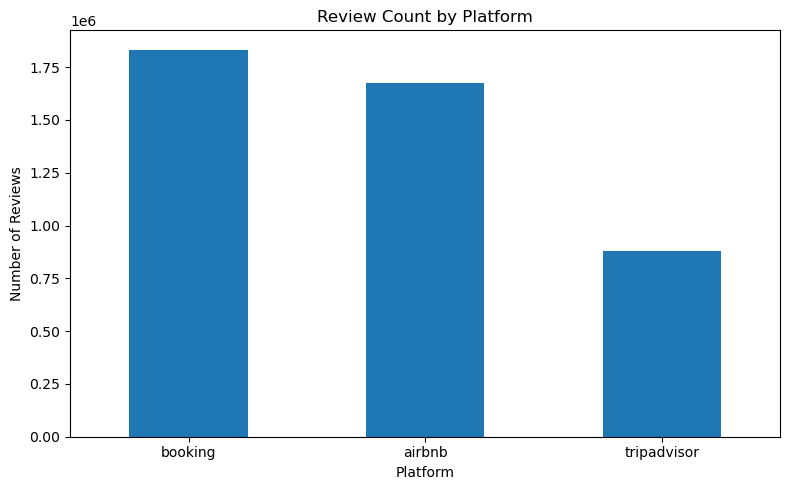

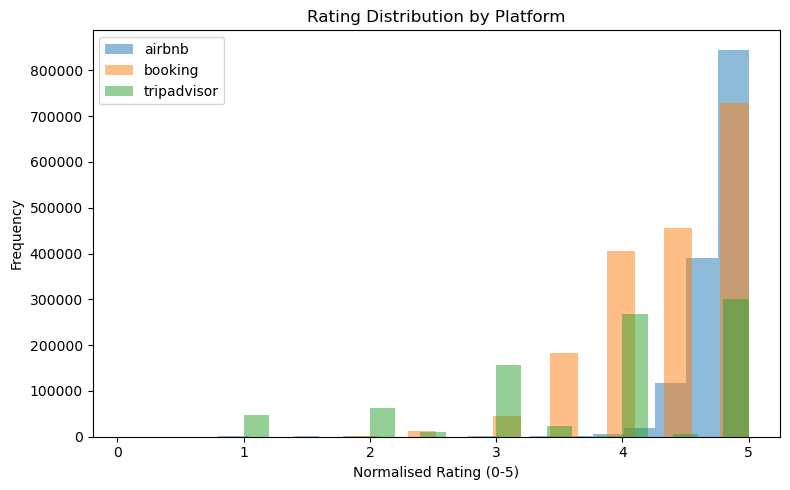

In [23]:
platform_counts = eda_df["platform"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
platform_counts.plot(kind="bar")
plt.title("Review Count by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

eda_plot_df = eda_df.dropna(subset=["rating_norm"]).copy()

plt.figure(figsize=(8, 5))
for p in sorted(eda_plot_df["platform"].dropna().unique()):
    subset = eda_plot_df.loc[eda_plot_df["platform"] == p, "rating_norm"]
    plt.hist(subset, bins=20, alpha=0.5, label=p)

plt.title("Rating Distribution by Platform")
plt.xlabel("Normalised Rating (0-5)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


# Part E2. Additional data-quality audits

This section adds focused audits to strengthen the benchmark dataset:

1. **Platform imbalance audit** 
2. **Suspicious / high-similarity review audit**
3. **City quality audit**

These checks are exploratory data-quality diagnostics. High similarity does **not** prove fake reviews, but it provides a useful heuristic for suspicious or non-independent review content.

## Section 18A. Create helper fields for audit analysis

In [24]:
import re

audit_df = all_reviews.copy()

print("audit_df created:", audit_df.shape)
print(audit_df.columns.tolist())

audit_df created: (4387455, 14)
['platform', 'city', 'entity_id', 'entity_name', 'review_text', 'rating_raw', 'rating_norm', 'review_date', 'reviewer_name', 'source_file', 'review_word_count', 'review_char_count', 'is_long_review', 'high_rating']


In [25]:
def clean_review_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# review_text_clean
if "review_text_clean" not in audit_df.columns:
    if "review_text" in audit_df.columns:
        audit_df["review_text_clean"] = audit_df["review_text"].astype(str).apply(clean_review_text)
    else:
        raise KeyError("`review_text` column not found.")

# word_count
if "word_count" not in audit_df.columns:
    if "review_word_count" in audit_df.columns:
        audit_df["word_count"] = pd.to_numeric(audit_df["review_word_count"], errors="coerce").fillna(0).astype(int)
    else:
        audit_df["word_count"] = (
            audit_df["review_text_clean"]
            .fillna("")
            .astype(str)
            .str.split()
            .str.len()
            .fillna(0)
            .astype(int)
        )

# high_rating
if "high_rating" not in audit_df.columns:
    if "rating_norm" in audit_df.columns:
        audit_df["rating_norm"] = pd.to_numeric(audit_df["rating_norm"], errors="coerce")
        audit_df["high_rating"] = np.where(audit_df["rating_norm"] >= 4.0, 1, 0)
        audit_df.loc[audit_df["rating_norm"].isna(), "high_rating"] = np.nan
    else:
        raise KeyError("`rating_norm` column not found.")

print(audit_df[["platform", "entity_id", "word_count", "rating_norm", "high_rating"]].head())

  platform  entity_id  word_count  rating_norm  high_rating
0   airbnb     103760         167         4.47            1
1   airbnb     103760          46         4.47            1
2   airbnb     103760          35         4.47            1
3   airbnb     103760          40         4.47            1
4   airbnb     103760         122         4.47            1


In [26]:
platform_audit_summary = (
    audit_df.groupby("platform")
    .agg(
        rows=("platform", "size"),
        unique_entities=("entity_id", "nunique"),
        non_missing_rating=("rating_norm", lambda s: s.notna().sum()),
        avg_rating=("rating_norm", "mean"),
        median_rating=("rating_norm", "median"),
        avg_word_count=("word_count", "mean"),
        median_word_count=("word_count", "median"),
        long_review_rate=("word_count", lambda s: (s >= 100).mean()),
        high_rating_rate=("high_rating", "mean")
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)

platform_audit_summary["row_share"] = (
    platform_audit_summary["rows"] / platform_audit_summary["rows"].sum()
)
platform_audit_summary["entity_share"] = (
    platform_audit_summary["unique_entities"] / platform_audit_summary["unique_entities"].sum()
)
platform_audit_summary["reviews_per_entity"] = (
    platform_audit_summary["rows"] / platform_audit_summary["unique_entities"]
)

platform_audit_summary

,platform,rows,unique_entities,non_missing_rating,avg_rating,median_rating,avg_word_count,median_word_count,long_review_rate,high_rating_rate,row_share,entity_share,reviews_per_entity
1,booking,1832766,45000,1832766,4.435766,4.50,44.452604,32.0,0.085173,0.867848,0.417729,0.480113,40.728133
0,airbnb,1676128,44783,1383731,4.755665,4.81,41.994551,30.0,0.085671,0.821953,0.382027,0.477797,37.427774
2,tripadvisor,878561,3945,878561,3.824025,4.00,146.374191,112.0,0.562544,0.653442,0.200244,0.042090,222.702408


## Section 18B. Platform imbalance audit

In [27]:
def build_balanced_dataset(
    data,
    text_col="review_text_clean",
    target_col="high_rating",
    platform_col="platform",
    entity_col="entity_id",
    max_reviews_per_entity=100,
    n_per_platform=None,
    random_state=42
):
    out = data.dropna(subset=[text_col, target_col, platform_col, entity_col]).copy()
    out = out[out[text_col].str.strip().ne("")].copy()

    out = (
        out.groupby([platform_col, entity_col], group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), max_reviews_per_entity), random_state=random_state))
        .reset_index(drop=True)
    )

    counts = out[platform_col].value_counts()
    if n_per_platform is None:
        n_per_platform = counts.min()

    out = (
        out.groupby(platform_col, group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), n_per_platform), random_state=random_state))
        .reset_index(drop=True)
    )

    return out

balanced_audit_df = build_balanced_dataset(
    audit_df,
    text_col="review_text_clean",
    target_col="high_rating",
    platform_col="platform",
    entity_col="entity_id",
    max_reviews_per_entity=100,
    n_per_platform=min(300000, audit_df["platform"].value_counts().min())
)

print("balanced_audit_df shape:", balanced_audit_df.shape)
print("\nRows by platform:")
print(balanced_audit_df["platform"].value_counts())
print("\nUnique entities by platform:")
print(balanced_audit_df.groupby("platform")["entity_id"].nunique())

C:\Users\Mo\AppData\Local\Temp\ipykernel_36692\911336882.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max_reviews_per_entity), random_state=random_state))
C:\Users\Mo\AppData\Local\Temp\ipykernel_36692\911336882.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), n_per_platform), random_state=random_state))


balanced_audit_df shape: (842757, 16)

Rows by platform:
platform
airbnb         300000
booking        300000
tripadvisor    242757
Name: count, dtype: int64

Unique entities by platform:
platform
airbnb         35064
booking        43799
tripadvisor     3943
Name: entity_id, dtype: int64


## Section 18C. High-similarity review audit

This audit searches for highly similar review pairs **within the same entity**. It is designed as a heuristic screen for duplicated or templated reviews, not proof of fake reviews.

In [28]:
from sklearn.neighbors import NearestNeighbors

def detect_suspicious_reviews_within_entity(
    data,
    text_col="review_text_clean",
    entity_col="entity_id",
    platform_col="platform",
    similarity_threshold=0.92,
    min_reviews_per_entity=10,
    max_entities=200,
    top_k=5,
    max_features=15000
):
    work = data.dropna(subset=[text_col, entity_col]).copy()
    work = work[work[text_col].str.strip().ne("")].copy()

    entity_sizes = work[entity_col].value_counts()
    target_entities = entity_sizes[entity_sizes >= min_reviews_per_entity].index[:max_entities]
    work = work[work[entity_col].isin(target_entities)].copy()

    rows = []

    for entity_id, sub in work.groupby(entity_col):
        sub = sub.reset_index(drop=True)

        if len(sub) < 2:
            continue

        tfidf = TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            max_features=max_features
        )
        X = tfidf.fit_transform(sub[text_col])

        n_neighbors = min(top_k + 1, len(sub))
        nn = NearestNeighbors(n_neighbors=n_neighbors, metric="cosine")
        nn.fit(X)
        distances, indices = nn.kneighbors(X)

        for i in range(len(sub)):
            for dist, j in zip(distances[i][1:], indices[i][1:]):  # skip self
                sim = 1 - dist
                if sim >= similarity_threshold:
                    rows.append({
                        "platform": sub.loc[i, platform_col] if platform_col in sub.columns else None,
                        "entity_id": entity_id,
                        "similarity": sim,
                        "word_count_1": len(str(sub.loc[i, text_col]).split()),
                        "word_count_2": len(str(sub.loc[j, text_col]).split()),
                        "review_text_1": sub.loc[i, "review_text"] if "review_text" in sub.columns else sub.loc[i, text_col],
                        "review_text_2": sub.loc[j, "review_text"] if "review_text" in sub.columns else sub.loc[j, text_col],
                    })

    result = pd.DataFrame(rows)
    if len(result) == 0:
        return result

    return result.sort_values(["similarity", "entity_id"], ascending=[False, True]).reset_index(drop=True)

suspicious_reviews = detect_suspicious_reviews_within_entity(
    audit_df,
    text_col="review_text_clean",
    entity_col="entity_id",
    platform_col="platform",
    similarity_threshold=0.92,
    min_reviews_per_entity=10,
    max_entities=200,
    top_k=5
)

print("Number of suspicious review pairs:", len(suspicious_reviews))
suspicious_reviews.head(20)

Number of suspicious review pairs: 2408


,platform,entity_id,similarity,word_count_1,word_count_2,review_text_1,review_text_2
0,booking,-1942357227,1.0,1,2,Comfortable,So comfortable
1,booking,-1942357227,1.0,3,3,Location and price,Location and price
2,booking,-1942357227,1.0,3,3,Location and price,Location and price
3,booking,-1942357227,1.0,3,3,Location and price,Location and price
4,booking,-1942357227,1.0,3,3,Close to airport,Close to airport
5,booking,-1942357227,1.0,3,3,Close to airport,Close to airport
6,booking,-1942357227,1.0,3,3,Close to airport,Close to airport
7,booking,-1942357227,1.0,3,3,Location and price,Location and price
8,booking,-1942357227,1.0,3,3,Location and price,Location and price
9,booking,-1942357227,1.0,3,3,Location and price,Location and price


In [29]:
if len(suspicious_reviews) > 0:
    suspicious_platform_summary = (
        suspicious_reviews.groupby("platform")
        .agg(
            suspicious_pairs=("similarity", "size"),
            avg_similarity=("similarity", "mean"),
            median_similarity=("similarity", "median")
        )
        .reset_index()
        .sort_values("suspicious_pairs", ascending=False)
    )

    suspicious_entity_summary = (
        suspicious_reviews.groupby(["platform", "entity_id"])
        .agg(
            suspicious_pairs=("similarity", "size"),
            max_similarity=("similarity", "max"),
            avg_similarity=("similarity", "mean")
        )
        .reset_index()
        .sort_values(["suspicious_pairs", "max_similarity"], ascending=[False, False])
    )
else:
    suspicious_platform_summary = pd.DataFrame(
        columns=["platform", "suspicious_pairs", "avg_similarity", "median_similarity"]
    )
    suspicious_entity_summary = pd.DataFrame(
        columns=["platform", "entity_id", "suspicious_pairs", "max_similarity", "avg_similarity"]
    )

print("Suspicious review summary by platform:")
display(suspicious_platform_summary)

print("Top entities with suspicious review pairs:")
display(suspicious_entity_summary.head(20))

Suspicious review summary by platform:


,platform,suspicious_pairs,avg_similarity,median_similarity
2,tripadvisor,1436,0.997235,1.0
0,airbnb,542,0.998817,1.0
1,booking,430,0.999241,1.0


Top entities with suspicious review pairs:


,platform,entity_id,suspicious_pairs,max_similarity,avg_similarity
2,airbnb,19670926,311,1.0,1.000000
105,tripadvisor,214197,137,1.0,1.000000
3,airbnb,21811046,116,1.0,1.000000
130,tripadvisor,611947,105,1.0,0.995514
11,booking,-2445992,99,1.0,1.000000
13,booking,436580214,84,1.0,1.000000
0,airbnb,2126708,77,1.0,0.991671
28,tripadvisor,80793,60,1.0,0.998778
64,tripadvisor,93450,52,1.0,1.000000
70,tripadvisor,93507,52,1.0,1.000000


In [30]:
duplicate_rate_by_entity = (
    audit_df.dropna(subset=["entity_id", "review_text_clean"])
    .groupby(["platform", "entity_id"])
    .agg(
        total_reviews=("review_text_clean", "size"),
        unique_reviews=("review_text_clean", "nunique")
    )
    .reset_index()
)

duplicate_rate_by_entity["duplicate_reviews"] = (
    duplicate_rate_by_entity["total_reviews"] - duplicate_rate_by_entity["unique_reviews"]
)
duplicate_rate_by_entity["duplicate_rate"] = (
    duplicate_rate_by_entity["duplicate_reviews"] / duplicate_rate_by_entity["total_reviews"]
)

duplicate_rate_by_entity.sort_values("duplicate_rate", ascending=False).head(20)

,platform,entity_id,total_reviews,unique_reviews,duplicate_reviews,duplicate_rate
40908,airbnb,1313720000000000000,60,3,57,0.950000
37683,airbnb,1141830000000000000,48,3,45,0.937500
37612,airbnb,1133060000000000000,600,38,562,0.936667
42999,airbnb,1416720000000000000,92,8,84,0.913043
40110,airbnb,1278840000000000000,209,19,190,0.909091
36309,airbnb,1039120000000000000,20,2,18,0.900000
42359,airbnb,1390400000000000000,10,1,9,0.900000
38355,airbnb,1182400000000000000,288,32,256,0.888889
38374,airbnb,1183620000000000000,18,2,16,0.888889
35863,airbnb,1014280000000000000,80,9,71,0.887500


## Section 18D. Location and city quality audit (supplementary only)

This section checks whether location metadata enough for audit and descriptive use.  

In [31]:
if "audit_df" not in globals():
    raise RuntimeError("Please run Section 18A first so that `audit_df` exists before the city-quality audit.")

def clean_city_name(x):
    x = str(x).strip().lower()
    x = re.sub(r"[\s\-]+", "_", x)

    mapping = {
        "hk": "hong_kong",
        "hongkong": "hong_kong",
        "hong_kong_sar": "hong_kong",
        "hong_kong,_china": "hong_kong",
        "hong_kong_china": "hong_kong",
        "greater_london": "london",
        "london_uk": "london",
        "istanbul_turkey": "istanbul"
    }
    return mapping.get(x, x)

# Defensive fallback only if earlier audit helper fields were skipped.
if "review_text_clean" not in audit_df.columns:
    audit_df["review_text_clean"] = audit_df["review_text"].astype(str).apply(clean_review_text)

if "word_count" not in audit_df.columns:
    if "review_word_count" in audit_df.columns:
        audit_df["word_count"] = pd.to_numeric(audit_df["review_word_count"], errors="coerce").fillna(0).astype(int)
    else:
        audit_df["word_count"] = (
            audit_df["review_text_clean"].fillna("").astype(str).str.split().str.len().fillna(0).astype(int)
        )

if "high_rating" not in audit_df.columns:
    audit_df["rating_norm"] = pd.to_numeric(audit_df["rating_norm"], errors="coerce")
    audit_df["high_rating"] = np.where(audit_df["rating_norm"] >= 4.0, 1, 0)

audit_df["city_clean"] = audit_df["city"].apply(clean_city_name)


In [32]:
valid_cities = {"hong_kong", "london", "istanbul"}

city_quality_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "missing_or_blank_city_rows",
        "missing_or_blank_city_rate",
        "unique_raw_city_values",
        "unique_clean_city_values",
        "invalid_city_rows",
        "invalid_city_rate"
    ],
    "value": [
        len(audit_df),
        (
            (audit_df["city"].isna()) |
            (audit_df["city"].astype(str).str.strip() == "") |
            (audit_df["city"].str.lower().isin(["nan", "none", "null", "unknown"]))
        ).sum(),
        (
            (audit_df["city"].isna()) |
            (audit_df["city"].astype(str).str.strip() == "") |
            (audit_df["city"].str.lower().isin(["nan", "none", "null", "unknown"]))
        ).mean(),
        audit_df["city"].nunique(dropna=True),
        audit_df["city_clean"].nunique(dropna=True),
        (~audit_df["city_clean"].isin(valid_cities)).sum(),
        (~audit_df["city_clean"].isin(valid_cities)).mean()
    ]
})

city_quality_summary

,metric,value
0,total_rows,4.387455e+06
1,missing_or_blank_city_rows,2.711327e+06
2,missing_or_blank_city_rate,6.179726e-01
3,unique_raw_city_values,3.000000e+00
4,unique_clean_city_values,4.000000e+00
5,invalid_city_rows,2.711327e+06
6,invalid_city_rate,6.179726e-01


In [33]:
invalid_city_rows = audit_df[~audit_df["city_clean"].isin(valid_cities)].copy()

print("Top invalid / unexpected city values:")
invalid_city_rows["city"].value_counts().head(30)

Top invalid / unexpected city values:


Series([], Name: count, dtype: int64)

In [34]:
entity_city_consistency = (
    audit_df.groupby(["platform", "entity_id"])["city_clean"]
    .nunique()
    .reset_index(name="n_cities")
)

multi_city_entities = entity_city_consistency[entity_city_consistency["n_cities"] > 1].copy()

print("Entities appearing in multiple cities:", len(multi_city_entities))
multi_city_entities.head(20)

Entities appearing in multiple cities: 0


,platform,entity_id,n_cities


In [35]:
if len(multi_city_entities) > 0:
    example_multi_city_ids = multi_city_entities["entity_id"].head(10).tolist()

    cols_to_show = ["platform", "entity_id", "city", "city_clean"]
    if "entity_name" in audit_df.columns:
        cols_to_show.insert(2, "entity_name")
    if "source_file" in audit_df.columns:
        cols_to_show.append("source_file")

    multi_city_examples = (
        audit_df[audit_df["entity_id"].isin(example_multi_city_ids)][cols_to_show]
        .sort_values(["entity_id", "city_clean"])
    )
else:
    multi_city_examples = pd.DataFrame()

multi_city_examples.head(50)

""


In [36]:
def expected_city_from_source(source_file):
    s = str(source_file).lower()
    if "hk" in s or "hong" in s:
        return "hong_kong"
    elif "london" in s:
        return "london"
    elif "istanbul" in s:
        return "istanbul"
    return None

if "source_file" in audit_df.columns:
    audit_df["expected_city_from_source"] = audit_df["source_file"].apply(expected_city_from_source)

    source_city_mismatch = audit_df[
        audit_df["expected_city_from_source"].notna() &
        (audit_df["city_clean"] != audit_df["expected_city_from_source"])
    ].copy()

    print("Source-file city mismatches:", len(source_city_mismatch))
    display(source_city_mismatch[["source_file", "city", "city_clean", "expected_city_from_source"]].head(30))
else:
    print("`source_file` column not found. Source-file city check skipped.")

Source-file city mismatches: 0


,source_file,city,city_clean,expected_city_from_source


## Section 18E. Combined audit summary

In [37]:
final_audit_summary = platform_audit_summary.copy()

if len(suspicious_platform_summary) > 0:
    final_audit_summary = final_audit_summary.merge(
        suspicious_platform_summary,
        on="platform",
        how="left"
    )
else:
    final_audit_summary["suspicious_pairs"] = np.nan
    final_audit_summary["avg_similarity"] = np.nan
    final_audit_summary["median_similarity"] = np.nan

final_audit_summary

,platform,rows,unique_entities,non_missing_rating,avg_rating,median_rating,avg_word_count,median_word_count,long_review_rate,high_rating_rate,row_share,entity_share,reviews_per_entity,suspicious_pairs,avg_similarity,median_similarity
0,booking,1832766,45000,1832766,4.435766,4.50,44.452604,32.0,0.085173,0.867848,0.417729,0.480113,40.728133,430,0.999241,1.0
1,airbnb,1676128,44783,1383731,4.755665,4.81,41.994551,30.0,0.085671,0.821953,0.382027,0.477797,37.427774,542,0.998817,1.0
2,tripadvisor,878561,3945,878561,3.824025,4.00,146.374191,112.0,0.562544,0.653442,0.200244,0.042090,222.702408,1436,0.997235,1.0


## Section 18F. Rating-anomaly diagnosis and suspicious-review bridge


In [38]:
duplicate_entity_platform_summary = (
    duplicate_rate_by_entity.groupby("platform", as_index=False)
    .agg(
        mean_duplicate_rate=("duplicate_rate", "mean"),
        median_duplicate_rate=("duplicate_rate", "median"),
        mean_duplicate_reviews=("duplicate_reviews", "mean"),
        entities_with_any_duplicate=("duplicate_reviews", lambda s: int((s > 0).sum())),
    )
)

rating_anomaly_summary = (
    platform_audit_summary
    .merge(
        suspicious_platform_summary.rename(columns={"avg_similarity": "avg_suspicious_similarity"}),
        on="platform",
        how="left"
    )
    .merge(
        duplicate_entity_platform_summary,
        on="platform",
        how="left"
    )
    .assign(
        low_rating_share=lambda d: np.where(d["avg_rating"].notna(), (d["avg_rating"] <= 3.5).astype(int), np.nan)
    )
)

display(rating_anomaly_summary)

trip_diag = audit_df[audit_df["platform"].astype(str).str.lower() == "tripadvisor"].copy()
trip_diag["low_rating_flag"] = (pd.to_numeric(trip_diag["rating_norm"], errors="coerce") <= 2).fillna(False).astype(int)

trip_diag["dup_key_within_entity"] = (
    trip_diag["entity_id"].astype(str).fillna("missing_entity") + "||" +
    trip_diag["review_text_clean"].fillna("").astype(str)
)
trip_dup_counts = trip_diag["dup_key_within_entity"].value_counts(dropna=False).to_dict()
trip_diag["duplicate_within_entity_flag"] = (
    trip_diag["dup_key_within_entity"].map(trip_dup_counts).fillna(0).astype(int) >= 2
).astype(int)

tripadvisor_low_rating_profile = (
    trip_diag.groupby("low_rating_flag", as_index=False)
    .agg(
        rows=("platform", "size"),
        mean_rating=("rating_norm", "mean"),
        mean_word_count=("word_count", "mean"),
        duplicate_within_entity_rate=("duplicate_within_entity_flag", "mean"),
    )
)

print("Tripadvisor low-rating profile (0 = other reviews, 1 = rating_norm <= 2):")
display(tripadvisor_low_rating_profile)

tripadvisor_low_rating_samples = trip_diag.loc[
    trip_diag["low_rating_flag"] == 1,
    [c for c in ["entity_id", "entity_name", "rating_norm", "review_text"] if c in trip_diag.columns]
].head(15)

tripadvisor_low_rating_dup_samples = trip_diag.loc[
    (trip_diag["low_rating_flag"] == 1) & (trip_diag["duplicate_within_entity_flag"] == 1),
    [c for c in ["entity_id", "entity_name", "rating_norm", "review_text"] if c in trip_diag.columns]
].head(15)

print("Sample Tripadvisor low-rating reviews:")
display(tripadvisor_low_rating_samples)

print("Sample Tripadvisor low-rating reviews that also look duplicated within entity:")
display(tripadvisor_low_rating_dup_samples)

,platform,rows,unique_entities,non_missing_rating,avg_rating,median_rating,avg_word_count,median_word_count,long_review_rate,high_rating_rate,...,entity_share,reviews_per_entity,suspicious_pairs,avg_suspicious_similarity,median_similarity,mean_duplicate_rate,median_duplicate_rate,mean_duplicate_reviews,entities_with_any_duplicate,low_rating_share
0,booking,1832766,45000,1832766,4.435766,4.50,44.452604,32.0,0.085173,0.867848,...,0.480113,40.728133,430,0.999241,1.0,0.000676,0.0,0.033556,855,0.0
1,airbnb,1676128,44783,1383731,4.755665,4.81,41.994551,30.0,0.085671,0.821953,...,0.477797,37.427774,542,0.998817,1.0,0.026768,0.0,1.342987,10171,0.0
2,tripadvisor,878561,3945,878561,3.824025,4.00,146.374191,112.0,0.562544,0.653442,...,0.042090,222.702408,1436,0.997235,1.0,0.001686,0.0,0.711027,691,0.0


Tripadvisor low-rating profile (0 = other reviews, 1 = rating_norm <= 2):


,low_rating_flag,rows,mean_rating,mean_word_count,duplicate_within_entity_rate
0,0,766798,4.152969,140.879192,0.004922
1,1,111763,1.567163,184.074989,0.004223


Sample Tripadvisor low-rating reviews:


,entity_id,entity_name,rating_norm,review_text
3578250,1641016,The Chatwal,1.0,A very bad experience. The entrance is narrow ...
3578259,93396,The Iroquois,1.0,"I arrived around 8:30 p.m., calling ahead to t..."
3578265,93559,The Sherry-Netherland Hotel,1.0,The information about the Sherry-Netherland is...
3578280,1641016,The Chatwal,1.0,"delayed check in (computers were down), entere..."
3578296,1641016,The Chatwal,1.0,"From the first night we stayed at this hotel, ..."
3578328,93559,The Sherry-Netherland Hotel,1.0,My husband and I stayed at the Sherry for two ...
3578341,1776857,"The Setai Fifth Avenue, a Capella managed Hotel",2.0,This is a place that can't decide whether it w...
3578367,98952,Four Seasons Hotel Houston,2.0,I stayed two nights here. First my room was no...
3578370,283873,"Hotel Icon, Autograph Collection",2.0,We booked a suite on the Pent House floor on o...
3578378,93559,The Sherry-Netherland Hotel,2.0,"Stayed there in May'12 for 2 nights, doing bus..."


Sample Tripadvisor low-rating reviews that also look duplicated within entity:


,entity_id,entity_name,rating_norm,review_text
3584159,107884,Americas Best Value Inn & Suites - Houston/Nor...,1.0,Oh my goodness!! The first sight we see when g...
3584160,107884,Americas Best Value Inn & Suites - Houston/Nor...,1.0,Oh my goodness!! The first sight we see when g...
3587099,107718,America's Inn,2.0,In the surrounding area is nothing. And when I...
3587100,107718,America's Inn,2.0,In the surrounding area is nothing. And when I...
3587168,107718,America's Inn,2.0,Unexpected good hotel. Since we are budget tra...
3587169,107718,America's Inn,2.0,Unexpected good hotel. Since we are budget tra...
3602604,93419,"The Carlyle, A Rosewood Hotel",1.0,アッパーイーストサイドにあるカーライルは古くから世界中のＶＩＰが定宿としていたことで知られて...
3603759,224224,"The Ritz-Carlton New York, Central Park",2.0,立地は申し分なくいいのですが、値段の割に外観もビルの一角といった感じでした。 同じ値段を出す...
3607315,1383001,Comfort Inn Manhattan Bridge,2.0,In dit hotel verbleven we 6 nachten rond de ja...
3607316,1383001,Comfort Inn Manhattan Bridge,2.0,In dit hotel verbleven we 6 nachten rond de ja...


### Short interpretation notes

- Platforms with a lower entity_share but high rows may be concentrated on fewer entities.
- High counts of suspicious review pairs may indicate duplicated or templated content, but they do **not** prove fake reviews.
- Invalid or inconsistent city values usually indicate extraction, mapping, or merge issues rather than fake records.


# Part F. Airbnb Data Development Index (ADDI)

## Section 19. Define ADDI scoring functions

### ADDI formula

\[
ADDI = 0.15(\text{Coverage}) + 0.20(\text{Completeness}) + 0.20(\text{Consistency}) + 0.20(\text{Quality}) + 0.25(\text{Strategic Readiness})
\]

### Revised Coverage formula

\[
Coverage = 100 \times (0.40R + 0.35E + 0.15P + 0.10G)
\]

where:

- \(R\) = review coverage
- \(E\) = entity coverage
- \(P\) = platform coverage
- \(G\) = geographic metadata usability

In [39]:
if "audit_df" in globals():
    _base_after_df = audit_df.copy()
    _base_name = "audit_df"
else:
    _base_after_df = all_reviews.copy()
    _base_name = "all_reviews"

print(f"[INFO] AFTER dataset source = {_base_name}")
print(f"[INFO] AFTER dataset shape  = {_base_after_df.shape}")


[INFO] AFTER dataset source = audit_df
[INFO] AFTER dataset shape  = (4387455, 18)


In [40]:
def clipped_ratio(value, target):
    if target is None or target == 0 or pd.isna(target):
        return 0.0
    if pd.isna(value):
        return 0.0
    return float(np.clip(value / target, 0, 1))

def pct_bool(series_bool):
    if len(series_bool) == 0:
        return 0.0
    return float(series_bool.mean())

def safe_series(df, col, default=""):
    if col in df.columns:
        return df[col]
    return pd.Series([default] * len(df), index=df.index)

def normalized_string(series):
    return (
        series.fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

def known_string(series):
    return ~normalized_string(series).isin(["", "nan", "none", "unknown", "missing", "invalid"])

def non_empty_text(series):
    return series.fillna("").astype(str).str.strip().ne("")

def valid_rating(series):
    x = pd.to_numeric(series, errors="coerce")
    return x.between(0, 5, inclusive="both") & x.notna()

def placeholder_text(series):
    s = normalized_string(series)
    placeholders = {
        "", "-", "--", "n/a", "na", "none", "nil",
        "nothing", "nothing.", "no complaints", "all good",
        "no negative", "no negative comments", "no complaints.", "not applicable"
    }
    return s.isin(placeholders)

def build_geo_metadata_usable(df):
    data = df.copy()

    platform = normalized_string(safe_series(data, "platform"))
    city = known_string(safe_series(data, "city"))
    city_meta = known_string(safe_series(data, "city_meta"))
    location_meta = known_string(safe_series(data, "location_meta"))
    source_file = normalized_string(safe_series(data, "source_file"))

    accommodation_country = known_string(safe_series(data, "accommodation_country"))
    locality = known_string(safe_series(data, "locality"))
    region = known_string(safe_series(data, "region"))

    booking_loc_flags = pd.Series(False, index=data.index)
    for col in ["location_is_ski", "location_is_beach", "location_is_city_center"]:
        if col in data.columns:
            booking_loc_flags = booking_loc_flags | safe_series(data, col).notna()

    airbnb_geo = city | city_meta | location_meta | source_file.str.contains("hong kong|hk|london|istanbul", na=False)
    booking_geo = accommodation_country | booking_loc_flags | city | city_meta
    trip_geo = locality | region | city | city_meta | location_meta
    generic_geo = city | city_meta | location_meta | accommodation_country | locality | region

    geo_usable = np.where(
        platform.eq("airbnb"), airbnb_geo,
        np.where(
            platform.eq("booking"), booking_geo,
            np.where(platform.eq("tripadvisor"), trip_geo, generic_geo)
        )
    )

    return pd.Series(geo_usable, index=data.index)

def compute_addi(
    df,
    model_df=None,
    target_reviews=2000000,      # stricter than v8.6
    target_entities=20000,       # stricter than v8.6
    target_platforms=3,
    min_platform_rows=50000,     # much stricter benchmark threshold
    weights=None
):
    data = df.copy()

    data["platform"] = normalized_string(safe_series(data, "platform"))
    data["city"] = normalized_string(safe_series(data, "city"))
    data["entity_id"] = safe_series(data, "entity_id").astype(str).str.strip()
    data["review_text"] = safe_series(data, "review_text").fillna("").astype(str)
    data["rating_norm"] = pd.to_numeric(safe_series(data, "rating_norm"), errors="coerce")
    data["review_date"] = pd.to_datetime(safe_series(data, "review_date"), errors="coerce")
    data["geo_metadata_usable"] = build_geo_metadata_usable(data)

    invalid_entity = data["entity_id"].isin(["", "nan", "none", "unknown", "missing", "invalid"])

   
    # 1. Coverage 
    n_reviews = len(data)
    n_entities = data.loc[~invalid_entity, "entity_id"].nunique()
    n_platforms = data.loc[known_string(data["platform"]), "platform"].nunique()

    R = clipped_ratio(n_reviews, target_reviews)
    E = clipped_ratio(n_entities, target_entities)
    P = clipped_ratio(n_platforms, target_platforms)

    geo_by_platform = (
        data.groupby("platform")["geo_metadata_usable"]
        .mean()
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    G = float(geo_by_platform.mean()) if len(geo_by_platform) > 0 else 0.0

    coverage_score = 100 * (0.40 * R + 0.35 * E + 0.15 * P + 0.10 * G)


    # 2. Completeness (stricter source/date emphasis)
    T = pct_bool(non_empty_text(data["review_text"]))
    Rc = pct_bool(data["rating_norm"].notna())
    Ec = pct_bool(~invalid_entity)
    D = pct_bool(data["review_date"].notna())

    if "source_file" in data.columns:
        S = pct_bool(known_string(data["source_file"]))
    else:
        S = pct_bool(known_string(data["platform"]))

    completeness_score = 100 * (0.28 * T + 0.25 * Rc + 0.20 * Ec + 0.17 * D + 0.10 * S)


    # 3. Consistency 
    required_cols = ["platform", "entity_id", "review_text", "rating_norm", "review_date", "source_file"]
    Sc = sum(col in data.columns for col in required_cols) / len(required_cols)
    Pc = pct_bool(data["platform"].isin(["airbnb", "booking", "tripadvisor"]))
    Rs = pct_bool(valid_rating(data["rating_norm"]))
    Es = pct_bool(~invalid_entity)

    consistency_score = 100 * (0.28 * Sc + 0.24 * Pc + 0.26 * Rs + 0.22 * Es)

  
    # 4. Quality 
    V = pct_bool(valid_rating(data["rating_norm"]))
    Tq = pct_bool(non_empty_text(data["review_text"]))

    dedup_key = pd.DataFrame({
        "platform": data["platform"],
        "entity_id": data["entity_id"],
        "review_date": data["review_date"].astype(str),
        "review_text_norm": normalized_string(data["review_text"]).str.replace(r"\s+", " ", regex=True)
    })
    duplicate_mask = dedup_key.duplicated(keep="first")
    Df = pct_bool(~duplicate_mask)

    L = pct_bool(data["review_text"].fillna("").astype(str).str.len() >= 30)

    # stricter noise rule: placeholder + html-ish / broken text penalties
    review_norm = normalized_string(data["review_text"])
    html_noise = review_norm.str.contains(r"<br\s*/?>|nbsp;|http|www\.", regex=True, na=False)
    N = pct_bool((~placeholder_text(data["review_text"])) & (~html_noise))

    quality_score = 100 * (0.25 * V + 0.18 * Tq + 0.22 * Df + 0.20 * L + 0.15 * N)

    # 5. Strategic Readiness (stricter)
    minimally_usable = (
        non_empty_text(data["review_text"]) &
        valid_rating(data["rating_norm"]) &
        (~invalid_entity) &
        data["platform"].isin(["airbnb", "booking", "tripadvisor"]) &
        data["review_date"].notna()
    )

    U = pct_bool(minimally_usable)

    usable_by_platform = data.loc[minimally_usable].groupby("platform").size()
    if len(usable_by_platform) > 0:
        B = float((usable_by_platform >= min_platform_rows).mean())
    else:
        B = 0.0

    # stricter than old min(len(model_df)/len(data),1)
    if model_df is not None and len(data) > 0:
        M = min(len(model_df) / (0.80 * len(data)), 1.0)
    else:
        M = U * 0.85

    platform_share = data["platform"].value_counts(normalize=True, dropna=True)
    if len(platform_share) > 1:
        hhi = float(np.sum(platform_share ** 2))
        Pb = 1 - ((hhi - 1/3) / (1 - 1/3))
        Pb = float(np.clip(Pb, 0, 1))
    else:
        Pb = 0.0

    strategic_readiness_score = 100 * (0.30 * U + 0.25 * B + 0.20 * M + 0.25 * Pb)

    if weights is None:
        weights = {
            "Coverage": 0.15,
            "Completeness": 0.20,
            "Consistency": 0.20,
            "Quality": 0.20,
            "Strategic Readiness": 0.25
        }

    dimension_scores = {
        "Coverage": coverage_score,
        "Completeness": completeness_score,
        "Consistency": consistency_score,
        "Quality": quality_score,
        "Strategic Readiness": strategic_readiness_score
    }

    overall_score = sum(dimension_scores[k] * weights[k] for k in dimension_scores.keys())

    dim_df = pd.DataFrame({
        "Dimension": list(dimension_scores.keys()),
        "Score": [round(v, 2) for v in dimension_scores.values()],
        "Weight": [weights[k] for k in dimension_scores.keys()],
        "Weighted Score Contribution": [
            round(dimension_scores[k] * weights[k], 2)
            for k in dimension_scores.keys()
        ]
    })

    detail_dict = {
        "n_reviews": n_reviews,
        "n_entities": n_entities,
        "n_platforms": n_platforms,
        "coverage_review_ratio_R": R,
        "coverage_entity_ratio_E": E,
        "coverage_platform_ratio_P": P,
        "coverage_geo_usability_G": G,
        "text_completeness_T": T,
        "rating_completeness_Rc": Rc,
        "entity_completeness_Ec": Ec,
        "date_completeness_D": D,
        "source_traceability_S": S,
        "schema_consistency_Sc": Sc,
        "platform_consistency_Pc": Pc,
        "rating_scale_consistency_Rs": Rs,
        "entity_key_consistency_Es": Es,
        "valid_rating_V": V,
        "non_empty_text_Tq": Tq,
        "duplicate_free_Df": Df,
        "text_length_L": L,
        "noise_free_N": N,
        "usable_rows_U": U,
        "benchmark_ready_platform_ratio_B": B,
        "model_ready_ratio_M": M,
        "platform_balance_Pb": Pb
    }

    return dim_df, round(overall_score, 2), detail_dict

def interpret_addi(score):
    if score >= 85:
        return "Very Strong"
    elif score >= 70:
        return "Strong"
    elif score >= 55:
        return "Moderate"
    elif score >= 40:
        return "Developing"
    else:
        return "Weak"

## Section 19A. Compute the ADDI score

This section applies the revised ADDI framework to the validated integrated dataset (primarily `audit_df`, or `all_reviews` if the audit dataframe is not yet available).

`model_df` is **not required** for the main ADDI computation. The ADDI is first a **data-readiness** assessment, not a model-performance score.

Important interpretation rule:
- `city` is **not** directly scored as a raw count target.
- location-related information enters the index through **geographic metadata usability** instead.


In [41]:
addi_dim_df, addi_score, addi_details = compute_addi(
    df=_base_after_df,
    model_df=model_df if "model_df" in globals() else None,
    target_reviews=800000,
    target_entities=5000,
    target_platforms=3,
    min_platform_rows=1000,
    weights={
        "Coverage": 0.15,
        "Completeness": 0.20,
        "Consistency": 0.20,
        "Quality": 0.20,
        "Strategic Readiness": 0.25
    }
)

addi_details_df = pd.DataFrame({
    "Metric": list(addi_details.keys()),
    "Value": list(addi_details.values())
})

print("===== Airbnb Data Development Index (ADDI) =====")
print(f"Overall ADDI Score: {addi_score:.2f} / 100")
print(f"Interpretation: {interpret_addi(addi_score)}")
display(addi_dim_df)
display(addi_details_df)


===== Airbnb Data Development Index (ADDI) =====
Overall ADDI Score: 87.73 / 100
Interpretation: Very Strong


,Dimension,Score,Weight,Weighted Score Contribution
0,Coverage,93.33,0.15,14.00
1,Completeness,88.77,0.20,17.75
2,Consistency,98.27,0.20,19.65
3,Quality,96.34,0.20,19.27
4,Strategic Readiness,68.22,0.25,17.05


,Metric,Value
0,n_reviews,4.387455e+06
1,n_entities,9.372800e+04
2,n_platforms,3.000000e+00
3,coverage_review_ratio_R,1.000000e+00
4,coverage_entity_ratio_E,1.000000e+00
5,coverage_platform_ratio_P,1.000000e+00
6,coverage_geo_usability_G,3.333333e-01
7,text_completeness_T,1.000000e+00
8,rating_completeness_Rc,9.333561e-01
9,entity_completeness_Ec,1.000000e+00


## Section 19B. Optional before-vs-after ADDI comparison

This section compares a **before ADDI** and **after ADDI** version.

- `after_addi_df` uses the final integrated cleaned dataset.
- `before_addi_df` uses a true earlier dataframe only if one exists in memory.
- Otherwise, the notebook creates a **degraded proxy before version** from the cleaned integrated dataset and clearly labels it as a fallback.

In [42]:
before_candidates = [
    "df_before",
    "before_df",
    "benchmark_raw",
    "merged_raw",
    "combined_raw",
    "raw_df",
    "all_reviews_raw"
]

found_before_name = None
for name in before_candidates:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, pd.DataFrame):
            found_before_name = name
            break

after_addi_df = _base_after_df.copy()

if found_before_name is not None:
    before_addi_df = globals()[found_before_name].copy()
    before_addi_source = f"Using true earlier dataframe: {found_before_name}"
    before_addi_is_proxy = False
else:
    before_addi_df = after_addi_df.copy()
    before_addi_source = "No true earlier dataframe found. Using degraded proxy before version derived from current cleaned data."
    before_addi_is_proxy = True

print("Before ADDI source:", before_addi_source)
print("Before ADDI proxy mode:", before_addi_is_proxy)
print("before_addi_df shape:", before_addi_df.shape)
print("after_addi_df shape:", after_addi_df.shape)


Before ADDI source: No true earlier dataframe found. Using degraded proxy before version derived from current cleaned data.
Before ADDI proxy mode: True
before_addi_df shape: (4387455, 18)
after_addi_df shape: (4387455, 18)


In [43]:

rng = np.random.default_rng(42)

before_addi_df = after_addi_df.copy()

def random_blank_out(df, col, frac, blank_value=np.nan):
    if col not in df.columns:
        return
    mask = rng.random(len(df)) < frac
    df.loc[mask, col] = blank_value

if "entity_id" in before_addi_df.columns:
    before_addi_df["entity_id"] = before_addi_df["entity_id"].astype("string")

for col in ["city", "city_meta", "location_meta", "entity_name", "language", "source_file", "review_text"]:
    if col in before_addi_df.columns:
        before_addi_df[col] = before_addi_df[col].astype("object")

if "rating_norm" in before_addi_df.columns:
    before_addi_df["rating_norm"] = pd.to_numeric(before_addi_df["rating_norm"], errors="coerce")

if "review_date" in before_addi_df.columns:
    before_addi_df["review_date"] = pd.to_datetime(before_addi_df["review_date"], errors="coerce")


# 1. harder missingness on metadata / structure
random_blank_out(before_addi_df, "city", 0.50, np.nan)
random_blank_out(before_addi_df, "city_meta", 0.50, np.nan)
random_blank_out(before_addi_df, "location_meta", 0.45, np.nan)
random_blank_out(before_addi_df, "entity_name", 0.40, np.nan)
random_blank_out(before_addi_df, "language", 0.35, np.nan)
random_blank_out(before_addi_df, "rating_norm", 0.30, np.nan)
random_blank_out(before_addi_df, "source_file", 0.25, np.nan)

if "review_date" in before_addi_df.columns:
    mask_bad_date = rng.random(len(before_addi_df)) < 0.40
    before_addi_df.loc[mask_bad_date, "review_date"] = pd.NaT


if "review_text" in before_addi_df.columns:
    review_text = before_addi_df["review_text"].fillna("").astype(str)

    mask_short = rng.random(len(before_addi_df)) < 0.20
    before_addi_df.loc[mask_short, "review_text"] = review_text.loc[mask_short].str.slice(0, 8)

    mask_empty = rng.random(len(before_addi_df)) < 0.08
    before_addi_df.loc[mask_empty, "review_text"] = ""

    mask_placeholder = rng.random(len(before_addi_df)) < 0.08
    before_addi_df.loc[mask_placeholder, "review_text"] = "nothing"


if "entity_id" in before_addi_df.columns:
    mask_bad_entity = rng.random(len(before_addi_df)) < 0.12
    before_addi_df.loc[mask_bad_entity, "entity_id"] = "unknown"

# 4. duplicate some rows harder than before
dup_n = int(len(before_addi_df) * 0.08)
if dup_n > 0:
    dup_rows = before_addi_df.sample(n=dup_n, random_state=42, replace=False)
    before_addi_df = pd.concat([before_addi_df, dup_rows], ignore_index=True)

print("Proxy before_addi_df prepared with stricter degradation.")
print("Rows:", len(before_addi_df))
if "platform" in before_addi_df.columns:
    print(before_addi_df["platform"].value_counts(dropna=False).head())
if "entity_id" in before_addi_df.columns:
    print("\nentity_id dtype:", before_addi_df["entity_id"].dtype)
if "review_date" in before_addi_df.columns:
    print("review_date dtype:", before_addi_df["review_date"].dtype)

Proxy before_addi_df prepared with stricter degradation.
Rows: 4738451
platform
booking        1979483
airbnb         1809926
tripadvisor     949042
Name: count, dtype: int64

entity_id dtype: string
review_date dtype: datetime64[ns]


In [44]:
addi_weights = {
    "Coverage": 0.15,
    "Completeness": 0.20,
    "Consistency": 0.20,
    "Quality": 0.20,
    "Strategic Readiness": 0.25
}

STRICT_TARGET_REVIEWS = 2000000
STRICT_TARGET_ENTITIES = 20000
STRICT_TARGET_PLATFORMS = 3
STRICT_MIN_PLATFORM_ROWS = 50000

before_addi_dim_df, before_addi_score, before_addi_details = compute_addi(
    df=before_addi_df,
    model_df=model_df if "model_df" in globals() else None,
    target_reviews=STRICT_TARGET_REVIEWS,
    target_entities=STRICT_TARGET_ENTITIES,
    target_platforms=STRICT_TARGET_PLATFORMS,
    min_platform_rows=STRICT_MIN_PLATFORM_ROWS,
    weights=addi_weights
)

after_addi_dim_df, after_addi_score, after_addi_details = compute_addi(
    df=after_addi_df,
    model_df=model_df if "model_df" in globals() else None,
    target_reviews=STRICT_TARGET_REVIEWS,
    target_entities=STRICT_TARGET_ENTITIES,
    target_platforms=STRICT_TARGET_PLATFORMS,
    min_platform_rows=STRICT_MIN_PLATFORM_ROWS,
    weights=addi_weights
)

print("===== BEFORE vs AFTER ADDI  =====")
print(f"Before ADDI Score: {before_addi_score:.2f} / 100")
print(f"Before Interpretation: {interpret_addi(before_addi_score)}")
print(f"After ADDI Score: {after_addi_score:.2f} / 100")
print(f"After Interpretation: {interpret_addi(after_addi_score)}")
print(f"Absolute Change: {after_addi_score - before_addi_score:.2f}")
if before_addi_score != 0:
    print(f"Percentage Change: {((after_addi_score - before_addi_score) / before_addi_score) * 100:.2f}%")
else:
    print("Percentage Change: NA (before score = 0)")


===== BEFORE vs AFTER ADDI  =====
Before ADDI Score: 75.07 / 100
Before Interpretation: Strong
After ADDI Score: 87.73 / 100
After Interpretation: Very Strong
Absolute Change: 12.66
Percentage Change: 16.86%


In [45]:
before_dim = before_addi_dim_df[["Dimension", "Weight", "Score"]].rename(
    columns={"Score": "Before Score"}
)

after_dim = after_addi_dim_df[["Dimension", "Weight", "Score"]].rename(
    columns={"Score": "After Score"}
)

addi_compare_df = before_dim.merge(
    after_dim[["Dimension", "After Score"]],
    on="Dimension",
    how="outer"
)

addi_compare_df["Change"] = addi_compare_df["After Score"] - addi_compare_df["Before Score"]
addi_compare_df["Weighted Change"] = addi_compare_df["Change"] * addi_compare_df["Weight"]

display(addi_compare_df.sort_values("Weight", ascending=False))

before_addi_details_df = pd.DataFrame({
    "Metric": list(before_addi_details.keys()),
    "Before Value": list(before_addi_details.values())
})

after_addi_details_df = pd.DataFrame({
    "Metric": list(after_addi_details.keys()),
    "After Value": list(after_addi_details.values())
})

addi_details_compare_df = before_addi_details_df.merge(
    after_addi_details_df,
    on="Metric",
    how="outer"
)

display(addi_details_compare_df)

,Dimension,Weight,Before Score,After Score,Change,Weighted Change
4,Strategic Readiness,0.25,55.58,68.22,12.64,3.1600
0,Completeness,0.20,71.84,88.77,16.93,3.3860
1,Consistency,0.20,88.35,98.27,9.92,1.9840
3,Quality,0.20,75.99,96.34,20.35,4.0700
2,Coverage,0.15,92.92,93.33,0.41,0.0615


,Metric,Before Value,After Value
0,benchmark_ready_platform_ratio_B,1.000000e+00,1.000000e+00
1,coverage_entity_ratio_E,1.000000e+00,1.000000e+00
2,coverage_geo_usability_G,2.915926e-01,3.333333e-01
3,coverage_platform_ratio_P,1.000000e+00,1.000000e+00
4,coverage_review_ratio_R,1.000000e+00,1.000000e+00
5,date_completeness_D,2.626297e-01,4.376328e-01
6,duplicate_free_Df,8.196934e-01,9.962518e-01
7,entity_completeness_Ec,8.800665e-01,1.000000e+00
8,entity_key_consistency_Es,8.800665e-01,1.000000e+00
9,model_ready_ratio_M,1.192931e-01,3.478863e-01


In [46]:
display(addi_compare_df)
display(addi_details_compare_df.head(10))

,Dimension,Weight,Before Score,After Score,Change,Weighted Change
0,Completeness,0.20,71.84,88.77,16.93,3.3860
1,Consistency,0.20,88.35,98.27,9.92,1.9840
2,Coverage,0.15,92.92,93.33,0.41,0.0615
3,Quality,0.20,75.99,96.34,20.35,4.0700
4,Strategic Readiness,0.25,55.58,68.22,12.64,3.1600


,Metric,Before Value,After Value
0,benchmark_ready_platform_ratio_B,1.000000,1.000000
1,coverage_entity_ratio_E,1.000000,1.000000
2,coverage_geo_usability_G,0.291593,0.333333
3,coverage_platform_ratio_P,1.000000,1.000000
4,coverage_review_ratio_R,1.000000,1.000000
5,date_completeness_D,0.262630,0.437633
6,duplicate_free_Df,0.819693,0.996252
7,entity_completeness_Ec,0.880067,1.000000
8,entity_key_consistency_Es,0.880067,1.000000
9,model_ready_ratio_M,0.119293,0.347886


## Section 19C. Visualise ADDI dimension scores

This chart summarises the five dimension scores and is useful for the methodology, findings, or presentation slides.

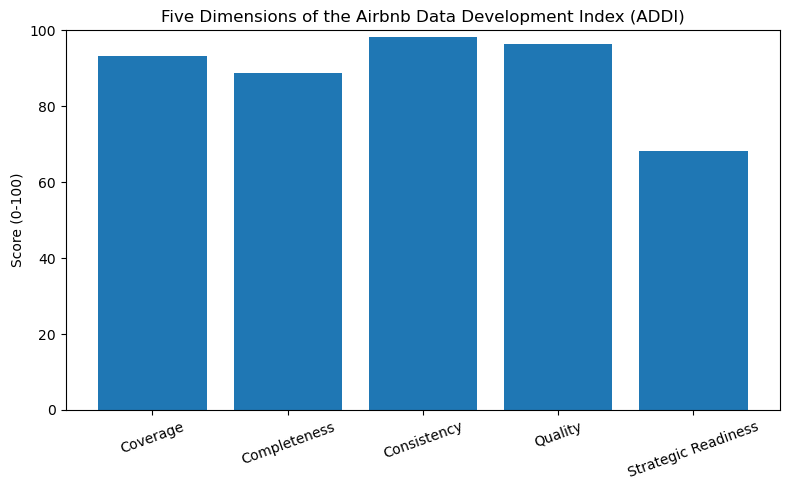

In [47]:
addi_plot_df = addi_dim_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(addi_plot_df["Dimension"], addi_plot_df["Score"])
plt.title("Five Dimensions of the Airbnb Data Development Index (ADDI)")
plt.ylabel("Score (0-100)")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Section 19D. Prepare ADDI outputs for the final curated export


In [48]:
if isinstance(addi_details, dict):
    addi_details_df = pd.DataFrame([addi_details])
else:
    addi_details_df = pd.DataFrame(addi_details)

addi_overall_df = pd.DataFrame({
    "index_name": ["ADDI"],
    "score": [addi_score],
    "interpretation": [interpret_addi(addi_score)]
})

report_addi_summary = pd.DataFrame({
    "Index": ["Airbnb Data Development Index (ADDI)"],
    "Overall Score": [addi_score],
    "Interpretation": [interpret_addi(addi_score)],
    "Coverage": [float(addi_dim_df.loc[addi_dim_df["Dimension"] == "Coverage", "Score"].iloc[0])],
    "Completeness": [float(addi_dim_df.loc[addi_dim_df["Dimension"] == "Completeness", "Score"].iloc[0])],
    "Consistency": [float(addi_dim_df.loc[addi_dim_df["Dimension"] == "Consistency", "Score"].iloc[0])],
    "Quality": [float(addi_dim_df.loc[addi_dim_df["Dimension"] == "Quality", "Score"].iloc[0])],
    "Strategic Readiness": [float(addi_dim_df.loc[addi_dim_df["Dimension"] == "Strategic Readiness", "Score"].iloc[0])]
})

display(addi_overall_df)
display(report_addi_summary)

,index_name,score,interpretation
0,ADDI,87.73,Very Strong


,Index,Overall Score,Interpretation,Coverage,Completeness,Consistency,Quality,Strategic Readiness
0,Airbnb Data Development Index (ADDI),87.73,Very Strong,93.33,88.77,98.27,96.34,68.22


# Part G. Core empirical design and benchmark tasks

## Section 20. Core empirical design, benchmark purpose, and strict interpretation rules


### Core row-retention policy

Rows may be excluded for the following reasons:

1. **Empty or unusable review text**  
  
2. **Missing or invalid target rating**  
 
3. **Out-of-range values after normalisation**  
 
4. **Unclear or weak metadata**  
  

In [49]:
from collections import defaultdict

from sklearn.metrics import (
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    ndcg_score,
)
from sklearn.metrics.pairwise import cosine_similarity

# Minimal-export mode: keep task paths available for optional intermediate export,
# but do not create extra folders unless EXPORT_INTERMEDIATE_TABLES is explicitly enabled.
BENCHMARK_DIR = Path(EXPORT_DIR) / "core_empirical_tasks"

CORE_TASK_DIRS = {
    "benchmark_input": BENCHMARK_DIR / "benchmark_input",
    "ranking_proxy": BENCHMARK_DIR / "ranking_proxy",
    "recommendation_proxy": BENCHMARK_DIR / "recommendation_proxy",
    "trust_safety_proxy": BENCHMARK_DIR / "trust_safety_proxy",
    "cross_platform_transfer": BENCHMARK_DIR / "cross_platform_transfer",
    "review_intelligence": BENCHMARK_DIR / "review_intelligence",
    "metadata_benchmarking": BENCHMARK_DIR / "metadata_benchmarking",
}

BENCHMARK_CONFIG = {
    "random_state": 42,
    "min_reviews_per_entity_for_entity_tasks": 5,
    "max_reviews_for_text_models": 120000,
    "max_entities_for_similarity": 12000,
    "tfidf_max_features": 25000,
    "recommendation_k": 10,
    "ranking_k": 10,
    "transfer_test_size": 0.25,
}

QUIET_EXPORTS = True

def safe_to_csv(df, path, index=False, quiet=QUIET_EXPORTS, force=False):
    path = Path(path)
    if df is None or (hasattr(df, "empty") and df.empty):
        return path

    if EXPORT_INTERMEDIATE_TABLES or force:
        path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(path, index=index)
        if not quiet:
            print(f"Saved: {path}")
    return path

def export_and_show(df, path, *, index=False, show="head", n=10, force=False):
    safe_to_csv(df, path, index=index, force=force)
    if show == "all":
        display(df)
    elif show == "head":
        display(df.head(n))
    elif show == "tail":
        display(df.tail(n))

def nonempty_text_mask(series):
    s = series.fillna("").astype(str).str.strip()
    return s.str.len() > 0

def add_drop_reason_flags(df):
    out = df.copy()
    out["flag_missing_text"] = ~nonempty_text_mask(out["review_text"])
    out["flag_missing_rating"] = out["rating_norm"].isna()
    out["flag_invalid_rating_range"] = ~out["rating_norm"].fillna(-999).between(0, 5, inclusive="both")
    out["flag_missing_entity_id"] = out["entity_id"].isna() | out["entity_id"].astype(str).str.strip().eq("")
    out["flag_missing_platform"] = out["platform"].isna() | out["platform"].astype(str).str.strip().eq("")
    return out

In [50]:

required_cols = [
    "platform",
    "city",
    "entity_id",
    "entity_name",
    "review_text",
    "rating_norm",
    "review_word_count",
    "review_char_count",
]

benchmark_input_df = all_reviews.copy()

for col in required_cols:
    if col not in benchmark_input_df.columns:
        benchmark_input_df[col] = np.nan

benchmark_input_df["review_text"] = benchmark_input_df["review_text"].fillna("").astype(str).str.strip()
benchmark_input_df["rating_norm"] = pd.to_numeric(benchmark_input_df["rating_norm"], errors="coerce")
benchmark_input_df["review_word_count"] = pd.to_numeric(benchmark_input_df["review_word_count"], errors="coerce")
benchmark_input_df["review_char_count"] = pd.to_numeric(benchmark_input_df["review_char_count"], errors="coerce")

benchmark_input_df = add_drop_reason_flags(benchmark_input_df)

benchmark_input_df["usable_for_text_tasks"] = (
    (~benchmark_input_df["flag_missing_text"]) &
    (~benchmark_input_df["flag_missing_platform"]) &
    (~benchmark_input_df["flag_missing_entity_id"])
)

benchmark_input_df["usable_for_supervised_rating_tasks"] = (
    benchmark_input_df["usable_for_text_tasks"] &
    (~benchmark_input_df["flag_missing_rating"]) &
    (~benchmark_input_df["flag_invalid_rating_range"])
)

benchmark_input_df["high_rating"] = np.where(
    benchmark_input_df["usable_for_supervised_rating_tasks"],
    (benchmark_input_df["rating_norm"] >= 4.0).astype(int),
    np.nan
)

benchmark_input_df["review_id_proxy"] = np.arange(len(benchmark_input_df)).astype(str)

benchmark_row_audit = pd.DataFrame({
    "metric": [
        "all_rows",
        "usable_for_text_tasks",
        "usable_for_supervised_rating_tasks",
        "missing_text_rows",
        "missing_rating_rows",
        "invalid_rating_range_rows",
        "missing_entity_id_rows",
    ],
    "value": [
        len(benchmark_input_df),
        int(benchmark_input_df["usable_for_text_tasks"].sum()),
        int(benchmark_input_df["usable_for_supervised_rating_tasks"].sum()),
        int(benchmark_input_df["flag_missing_text"].sum()),
        int(benchmark_input_df["flag_missing_rating"].sum()),
        int(benchmark_input_df["flag_invalid_rating_range"].sum()),
        int(benchmark_input_df["flag_missing_entity_id"].sum()),
    ]
})

benchmark_platform_audit = benchmark_input_df.groupby("platform", dropna=False).agg(
    rows=("platform", "size"),
    usable_for_text_tasks=("usable_for_text_tasks", "sum"),
    usable_for_supervised_rating_tasks=("usable_for_supervised_rating_tasks", "sum"),
    mean_rating=("rating_norm", "mean"),
    unique_entities=("entity_id", "nunique"),
).reset_index()

safe_to_csv(benchmark_input_df.head(20000), CORE_TASK_DIRS["benchmark_input"] / "benchmark_input_head_20000.csv", index=False)
safe_to_csv(benchmark_row_audit, CORE_TASK_DIRS["benchmark_input"] / "benchmark_row_audit.csv", index=False)
safe_to_csv(benchmark_platform_audit, CORE_TASK_DIRS["benchmark_input"] / "benchmark_platform_audit.csv", index=False)

display(benchmark_row_audit)
display(benchmark_platform_audit)

,metric,value
0,all_rows,4387455
1,usable_for_text_tasks,4385595
2,usable_for_supervised_rating_tasks,4094950
3,missing_text_rows,0
4,missing_rating_rows,292397
5,invalid_rating_range_rows,292397
6,missing_entity_id_rows,1860


,platform,rows,usable_for_text_tasks,usable_for_supervised_rating_tasks,mean_rating,unique_entities
0,airbnb,1676128,1674268,1383623,4.755665,44783
1,booking,1832766,1832766,1832766,4.435766,45000
2,tripadvisor,878561,878561,878561,3.824025,3945


In [51]:
entity_task_df = benchmark_input_df[
    benchmark_input_df["usable_for_supervised_rating_tasks"]
].copy()

entity_review_counts = (
    entity_task_df.groupby(["platform", "entity_id"])
    .size()
    .rename("n_reviews")
    .reset_index()
)

entity_base = (
    entity_task_df
    .groupby(["platform", "entity_id"], as_index=False)
    .agg(
        city=("city", "first"),
        entity_name=("entity_name", "first"),
        n_reviews=("review_id_proxy", "size"),
        mean_rating=("rating_norm", "mean"),
        median_rating=("rating_norm", "median"),
        high_rating_ratio=("high_rating", "mean"),
        avg_review_word_count=("review_word_count", "mean"),
        review_text_joined=("review_text", lambda s: " ".join(s.astype(str).head(50))),
    )
)

entity_base = entity_base[
    entity_base["n_reviews"] >= BENCHMARK_CONFIG["min_reviews_per_entity_for_entity_tasks"]
].copy()

entity_base["entity_label_high_quality"] = (entity_base["mean_rating"] >= 4.0).astype(int)

safe_to_csv(entity_base, CORE_TASK_DIRS["benchmark_input"] / "entity_task_dataset.csv", index=False)

display(entity_base.head())

,platform,entity_id,city,entity_name,n_reviews,mean_rating,median_rating,high_rating_ratio,avg_review_word_count,review_text_joined,entity_label_high_quality
0,airbnb,13913,london,None,55,4.85,4.85,1.0,40.636364,My girlfriend and I hadn't known Alina before ...,1
1,airbnb,15400,london,None,96,4.80,4.80,1.0,72.968750,We loved staying at Phillipa's place in Chelse...,1
2,airbnb,17402,london,None,54,4.77,4.77,1.0,58.222222,"Amazing location - great apartment, plenty of ...",1
3,airbnb,24328,london,None,94,4.90,4.90,1.0,68.510638,The communication with Joe was very easy. We r...,1
4,airbnb,34177,istanbul,None,16,4.69,4.69,1.0,86.562500,"Ercan is wonderful, as his family, and they wi...",1


In [52]:
from sklearn.preprocessing import MinMaxScaler

INVALID_CITY_TOKENS = {"", "unknown", "none", "nan", "na", "n/a", "null", "missing", "?", "-"}

def clean_city_token(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in INVALID_CITY_TOKENS:
        return np.nan
    return s

entity_index_df = entity_task_df.copy()
entity_index_df["city_clean"] = entity_index_df["city"].apply(clean_city_token)
entity_index_df["has_city_valid"] = entity_index_df["city_clean"].notna().astype(int)
entity_index_df["has_entity_name"] = entity_index_df["entity_name"].notna().astype(int)
entity_index_df["review_text_nonempty"] = entity_index_df["review_text"].fillna("").astype(str).str.strip().str.len().gt(0).astype(int)

entity_index_df["review_word_count"] = pd.to_numeric(entity_index_df["review_word_count"], errors="coerce")
entity_index_df["rating_norm"] = pd.to_numeric(entity_index_df["rating_norm"], errors="coerce")

entity_index_df = (
    entity_index_df.groupby(["platform", "entity_id"], as_index=False)
    .agg(
        city=("city_clean", "first"),
        entity_name=("entity_name", "first"),
        n_reviews=("review_text", "size"),
        mean_rating=("rating_norm", "mean"),
        std_rating=("rating_norm", "std"),
        mean_review_words=("review_word_count", "mean"),
        pct_nonempty_text=("review_text_nonempty", "mean"),
        pct_has_city=("has_city_valid", "mean"),
        pct_has_entity_name=("has_entity_name", "mean"),
        high_rating_ratio=("high_rating", "mean"),
    )
)

entity_index_df["std_rating"] = entity_index_df["std_rating"].fillna(0)
entity_index_df["mean_review_words"] = entity_index_df["mean_review_words"].fillna(0)

# Five structured dimensions aligned with the report logic
entity_index_df["idx_coverage"] = np.log1p(entity_index_df["n_reviews"])
entity_index_df["idx_completeness"] = (
    0.50 * entity_index_df["pct_nonempty_text"] +
    0.25 * entity_index_df["pct_has_city"] +
    0.25 * entity_index_df["pct_has_entity_name"]
)
entity_index_df["idx_consistency"] = 1 / (1 + entity_index_df["std_rating"])
entity_index_df["idx_quality"] = (
    0.60 * (entity_index_df["mean_rating"] / 5.0) +
    0.40 * np.clip(entity_index_df["mean_review_words"] / 50.0, 0, 1)
)
entity_index_df["idx_strategic_readiness"] = (
    0.50 * np.clip(np.log1p(entity_index_df["n_reviews"]) / np.log1p(entity_index_df["n_reviews"].max()), 0, 1) +
    0.50 * entity_index_df["high_rating_ratio"].fillna(0)
)

index_feature_cols = [
    "idx_coverage",
    "idx_completeness",
    "idx_consistency",
    "idx_quality",
    "idx_strategic_readiness",
]

scaler = MinMaxScaler()
entity_index_df[index_feature_cols] = scaler.fit_transform(entity_index_df[index_feature_cols])

entity_index_df["entity_index_score"] = (
    0.15 * entity_index_df["idx_coverage"] +
    0.20 * entity_index_df["idx_completeness"] +
    0.20 * entity_index_df["idx_consistency"] +
    0.20 * entity_index_df["idx_quality"] +
    0.25 * entity_index_df["idx_strategic_readiness"]
)

entity_index_export_path = CORE_TASK_DIRS["benchmark_input"] / "entity_index_features_v78.csv"
safe_to_csv(entity_index_df, entity_index_export_path, index=False)

print(f"Saved: {entity_index_export_path}")
display(entity_index_df.head())


Saved: C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Exports\core_empirical_tasks\benchmark_input\entity_index_features_v78.csv


,platform,entity_id,city,entity_name,n_reviews,mean_rating,std_rating,mean_review_words,pct_nonempty_text,pct_has_city,pct_has_entity_name,high_rating_ratio,idx_coverage,idx_completeness,idx_consistency,idx_quality,idx_strategic_readiness,entity_index_score
0,airbnb,13913,london,None,55,4.85,0.0,40.636364,1.0,1.0,0.0,1.0,0.421185,1.0,1.0,0.893453,0.779507,0.836745
1,airbnb,15400,london,None,96,4.80,0.0,72.968750,1.0,1.0,0.0,1.0,0.490623,1.0,1.0,0.972477,0.815381,0.871934
2,airbnb,17402,london,None,54,4.77,0.0,58.222222,1.0,1.0,0.0,1.0,0.418907,1.0,1.0,0.968349,0.778330,0.851088
3,airbnb,24328,london,None,94,4.90,0.0,68.510638,1.0,1.0,0.0,1.0,0.487989,1.0,1.0,0.986239,0.814021,0.873951
4,airbnb,34177,istanbul,None,16,4.69,0.0,86.562500,1.0,1.0,0.0,1.0,0.270500,1.0,1.0,0.957339,0.701657,0.807457


In [53]:
def precision_at_k(y_true_sorted, k):
    y = np.asarray(y_true_sorted)[:k]
    return float(np.mean(y == 1)) if len(y) > 0 else 0.0

def recall_at_k(y_true_sorted, k):
    y = np.asarray(y_true_sorted)
    denom = max(1, int(np.sum(y == 1)))
    return float(np.sum(y[:k] == 1) / denom)

ranking_df = entity_base.copy()

# Rebuild a stricter platform-aware proxy label:
# only the top 10% of entities by mean_rating within each platform are labelled high quality.
ranking_df["entity_label_high_quality_strict"] = (
    ranking_df.groupby("platform")["mean_rating"]
    .transform(lambda s: (s >= s.quantile(0.90)).astype(int))
    .astype(int)
)

ranking_features = ranking_df["review_text_joined"].fillna("").astype(str)
ranking_target = ranking_df["entity_label_high_quality_strict"].astype(int)

# mild sampling to control runtime for very large notebooks
if len(ranking_df) > BENCHMARK_CONFIG["max_entities_for_similarity"]:
    ranking_df = ranking_df.sample(
        BENCHMARK_CONFIG["max_entities_for_similarity"],
        random_state=BENCHMARK_CONFIG["random_state"]
    ).copy()
    ranking_features = ranking_df["review_text_joined"].fillna("").astype(str)
    ranking_target = ranking_df["entity_label_high_quality_strict"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    ranking_features,
    ranking_target,
    test_size=BENCHMARK_CONFIG["transfer_test_size"],
    random_state=BENCHMARK_CONFIG["random_state"],
    stratify=ranking_target
)

ranking_vectorizer = TfidfVectorizer(
    max_features=BENCHMARK_CONFIG["tfidf_max_features"],
    ngram_range=(1, 2),
    min_df=2
)

X_train_vec = ranking_vectorizer.fit_transform(X_train)
X_test_vec = ranking_vectorizer.transform(X_test)

ranking_model = LogisticRegression(max_iter=1000, class_weight="balanced")
ranking_model.fit(X_train_vec, y_train)

ranking_scores = ranking_model.predict_proba(X_test_vec)[:, 1]

ranking_eval_df = ranking_df.loc[
    X_test.index,
    ["platform", "city", "entity_id", "entity_name", "mean_rating"]
].copy()
ranking_eval_df["entity_label_high_quality_strict"] = y_test.astype(int)
ranking_eval_df["pred_score"] = ranking_scores

ranking_metrics_rows = []
k = BENCHMARK_CONFIG["ranking_k"]

for group_name, group_df in ranking_eval_df.groupby("platform"):
    g = group_df.sort_values("pred_score", ascending=False).reset_index(drop=True)
    y_true = g["entity_label_high_quality_strict"].astype(int).values
    y_score = g["pred_score"].astype(float).values

    positives = int(y_true.sum())
    if positives == 0:
        continue

    ranking_metrics_rows.append({
        "group_type": "platform",
        "group_name": group_name,
        "n_entities": len(g),
        "positive_entities": positives,
        "positive_rate": float(positives / len(g)) if len(g) > 0 else np.nan,
        "Hits@10": int(np.sum(y_true[:k])),
        "Precision@10": precision_at_k(y_true, k),
        "Recall@10": recall_at_k(y_true, k),
        "PR_AUC": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        "MAE_mean_rating_proxy": float(mean_absolute_error(g["mean_rating"], np.clip(y_score * 5, 0, 5))),
        "RMSE_mean_rating_proxy": float(np.sqrt(mean_squared_error(g["mean_rating"], np.clip(y_score * 5, 0, 5)))),
    })

ranking_metrics_df = (
    pd.DataFrame(ranking_metrics_rows)
    .sort_values(["group_type", "group_name"])
    .reset_index(drop=True)
)

# Quiet export
safe_to_csv(
    ranking_eval_df.sort_values("pred_score", ascending=False),
    CORE_TASK_DIRS["ranking_proxy"] / "ranking_proxy_entity_predictions.csv",
    index=False
)
safe_to_csv(
    ranking_metrics_df,
    CORE_TASK_DIRS["ranking_proxy"] / "ranking_proxy_metrics.csv",
    index=False
)

ranking_metrics_df

,group_type,group_name,n_entities,positive_entities,positive_rate,Hits@10,Precision@10,Recall@10,PR_AUC,MAE_mean_rating_proxy,RMSE_mean_rating_proxy
0,platform,airbnb,972,102,0.104938,4,0.4,0.039216,0.314253,3.194027,3.348213
1,platform,booking,1874,189,0.100854,10,1.0,0.052910,0.710160,3.220501,3.412973
2,platform,tripadvisor,154,13,0.084416,1,0.1,0.076923,0.190051,2.553527,2.641596


In [54]:
recommendation_df = entity_base.copy()

if len(recommendation_df) > BENCHMARK_CONFIG["max_entities_for_similarity"]:
    recommendation_df = recommendation_df.sample(
        BENCHMARK_CONFIG["max_entities_for_similarity"],
        random_state=BENCHMARK_CONFIG["random_state"]
    ).copy()

rec_vectorizer = TfidfVectorizer(
    max_features=BENCHMARK_CONFIG["tfidf_max_features"],
    ngram_range=(1, 2),
    min_df=2
)

rec_X = rec_vectorizer.fit_transform(recommendation_df["review_text_joined"].fillna("").astype(str))
rec_nn = NearestNeighbors(metric="cosine", algorithm="brute")
rec_nn.fit(rec_X)

distances, indices = rec_nn.kneighbors(
    rec_X,
    n_neighbors=min(BENCHMARK_CONFIG["recommendation_k"] + 1, len(recommendation_df))
)

def _clean_city_for_match(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    return np.nan if s in INVALID_CITY_TOKENS else s

recommendation_rows = []
for row_idx, neigh_idx in enumerate(indices):
    source_row = recommendation_df.iloc[row_idx]
    source_city_clean = _clean_city_for_match(source_row["city"])

    for rank_pos, n_idx in enumerate(neigh_idx[1:], start=1):  # skip self
        neighbor_row = recommendation_df.iloc[n_idx]
        neighbor_city_clean = _clean_city_for_match(neighbor_row["city"])
        city_pair_comparable = int(pd.notna(source_city_clean) and pd.notna(neighbor_city_clean))
        same_city_strict = int(city_pair_comparable and (source_city_clean == neighbor_city_clean))

        recommendation_rows.append({
            "source_platform": source_row["platform"],
            "source_entity_id": source_row["entity_id"],
            "source_entity_name": source_row["entity_name"],
            "source_city": source_row["city"],
            "source_city_clean": source_city_clean,
            "source_mean_rating": source_row["mean_rating"],
            "neighbor_rank": rank_pos,
            "neighbor_platform": neighbor_row["platform"],
            "neighbor_entity_id": neighbor_row["entity_id"],
            "neighbor_entity_name": neighbor_row["entity_name"],
            "neighbor_city": neighbor_row["city"],
            "neighbor_city_clean": neighbor_city_clean,
            "neighbor_mean_rating": neighbor_row["mean_rating"],
            "same_platform": int(source_row["platform"] == neighbor_row["platform"]),
            "city_pair_comparable": city_pair_comparable,
            "same_city_strict": same_city_strict,
            "rating_gap_abs": abs(float(source_row["mean_rating"]) - float(neighbor_row["mean_rating"])),
            "similarity": float(1 - distances[row_idx][rank_pos]),
        })

recommendation_pairs_df = pd.DataFrame(recommendation_rows)
recommendation_pairs_df["good_match_rating_gap_le_0_5"] = (recommendation_pairs_df["rating_gap_abs"] <= 0.5).astype(int)

recommendation_metrics_df = (
    recommendation_pairs_df.groupby("source_platform", as_index=False)
    .agg(
        mean_similarity=("similarity", "mean"),
        city_comparable_pair_rate=("city_pair_comparable", "mean"),
        mean_same_city_rate_strict=("same_city_strict", "mean"),
        mean_same_platform_rate=("same_platform", "mean"),
        mean_good_match_rate=("good_match_rating_gap_le_0_5", "mean"),
    )
)

valid_city_only_metrics_df = (
    recommendation_pairs_df[recommendation_pairs_df["city_pair_comparable"] == 1]
    .groupby("source_platform", as_index=False)
    .agg(mean_same_city_rate_valid_only=("same_city_strict", "mean"))
)

recommendation_metrics_df = recommendation_metrics_df.merge(
    valid_city_only_metrics_df,
    on="source_platform",
    how="left"
)

recommendation_pairs_export_path = CORE_TASK_DIRS["recommendation_proxy"] / "recommendation_proxy_pairs_v78.csv"
recommendation_metrics_export_path = CORE_TASK_DIRS["recommendation_proxy"] / "recommendation_proxy_metrics_v78.csv"

safe_to_csv(recommendation_pairs_df, recommendation_pairs_export_path, index=False)
safe_to_csv(recommendation_metrics_df, recommendation_metrics_export_path, index=False)

print(f"Saved: {recommendation_pairs_export_path}")
print(f"Saved: {recommendation_metrics_export_path}")
display(recommendation_metrics_df)


Saved: C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Exports\core_empirical_tasks\recommendation_proxy\recommendation_proxy_pairs_v78.csv
Saved: C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Exports\core_empirical_tasks\recommendation_proxy\recommendation_proxy_metrics_v78.csv


,source_platform,mean_similarity,city_comparable_pair_rate,mean_same_city_rate_strict,mean_same_platform_rate,mean_good_match_rate,mean_same_city_rate_valid_only
0,airbnb,0.560062,0.960277,0.914119,0.960277,0.927043,0.951933
1,booking,0.594470,0.000000,0.000000,0.825162,0.819004,NaN
2,tripadvisor,0.774138,0.000000,0.000000,0.997015,0.632836,NaN


In [55]:
ts_df = benchmark_input_df[benchmark_input_df["usable_for_text_tasks"]].copy()
ts_df["review_len"] = ts_df["review_text"].fillna("").astype(str).str.split().str.len()
ts_df["review_text_lower"] = ts_df["review_text"].fillna("").astype(str).str.lower()
ts_df["duplicate_key_within_entity"] = (
    ts_df["platform"].astype(str) + "||" +
    ts_df["entity_id"].astype(str) + "||" +
    ts_df["review_text_lower"].astype(str)
)

dup_counts = ts_df["duplicate_key_within_entity"].value_counts()
ts_df["duplicate_count_within_entity"] = ts_df["duplicate_key_within_entity"].map(dup_counts).fillna(1).astype(int)

entity_rating_std = (
    ts_df.groupby(["platform", "entity_id"])["rating_norm"]
    .std()
    .rename("entity_rating_std")
    .reset_index()
)

ts_df = ts_df.merge(entity_rating_std, on=["platform", "entity_id"], how="left")

ts_df["flag_very_short"] = (ts_df["review_len"] <= 3).astype(int)
ts_df["flag_duplicate_text_within_entity"] = (ts_df["duplicate_count_within_entity"] >= 2).astype(int)
ts_df["flag_extreme_positive"] = (ts_df["rating_norm"] >= 5).fillna(False).astype(int)
ts_df["flag_extreme_negative"] = (ts_df["rating_norm"] <= 1).fillna(False).astype(int)

ts_df["trust_safety_proxy_score"] = (
    0.35 * ts_df["flag_duplicate_text_within_entity"] +
    0.25 * ts_df["flag_very_short"] +
    0.20 * ts_df["flag_extreme_positive"] +
    0.20 * ts_df["flag_extreme_negative"]
)

ts_df["trust_safety_flag"] = (ts_df["trust_safety_proxy_score"] >= 0.35).astype(int)

trust_metrics_df = (
    ts_df.groupby("platform", as_index=False)
    .agg(
        rows=("platform", "size"),
        flagged_rows=("trust_safety_flag", "sum"),
        flagged_rate=("trust_safety_flag", "mean"),
        duplicate_rate=("flag_duplicate_text_within_entity", "mean"),
        very_short_rate=("flag_very_short", "mean"),
        extreme_positive_rate=("flag_extreme_positive", "mean"),
        extreme_negative_rate=("flag_extreme_negative", "mean"),
    )
)

safe_to_csv(
    ts_df.sort_values(["trust_safety_proxy_score", "duplicate_count_within_entity"], ascending=[False, False]),
    CORE_TASK_DIRS["trust_safety_proxy"] / "trust_safety_proxy_review_flags.csv",
    index=False
)
safe_to_csv(trust_metrics_df, CORE_TASK_DIRS["trust_safety_proxy"] / "trust_safety_proxy_metrics.csv", index=False)

display(trust_metrics_df)

,platform,rows,flagged_rows,flagged_rate,duplicate_rate,very_short_rate,extreme_positive_rate,extreme_negative_rate
0,airbnb,1674268,24931,0.014891,0.013825,0.067308,0.027521,0.000718
1,booking,1832766,8323,0.004541,0.001259,0.008374,0.398067,0.000039
2,tripadvisor,878561,2440,0.002777,0.002156,0.003782,0.341364,0.054250


## downstream check for the Trust & Safety proxy

This is not the main contribution. It is a downstream plausibility check.

In [56]:
ts_downstream_df = ts_df.copy()
ts_downstream_df = ts_downstream_df[ts_downstream_df["review_text"].fillna("").astype(str).str.strip() != ""].copy()
ts_downstream_df = ts_downstream_df[ts_downstream_df["entity_id"].notna()].copy()

if ts_downstream_df["entity_id"].nunique() >= 2 and ts_downstream_df["trust_safety_flag"].nunique() >= 2:
    ts_train_df, ts_test_df = strict_entity_split(
        ts_downstream_df,
        entity_col="entity_id",
        test_size=0.20,
        random_state=42
    )

    X_train_ts = ts_train_df["review_text"]
    X_test_ts = ts_test_df["review_text"]
    y_train_ts = ts_train_df["trust_safety_flag"]
    y_test_ts = ts_test_df["trust_safety_flag"]

    ts_pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=3)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ])

    ts_pipe.fit(X_train_ts, y_train_ts)
    y_pred_ts = ts_pipe.predict(X_test_ts)
    y_prob_ts = ts_pipe.predict_proba(X_test_ts)[:, 1]

    trust_safety_model_df = pd.DataFrame([{
        "model": "TF-IDF + Logistic Regression",
        "target": "trust_safety_flag",
        "split_type": "entity_id_strict",
        "accuracy": accuracy_score(y_test_ts, y_pred_ts),
        "f1_weighted": f1_score(y_test_ts, y_pred_ts, average="weighted"),
        "pr_auc": average_precision_score(y_test_ts, y_prob_ts),
        "n_train": len(X_train_ts),
        "n_test": len(X_test_ts),
        "n_train_entities": ts_train_df["entity_id"].nunique(),
        "n_test_entities": ts_test_df["entity_id"].nunique(),
    }])

    display(trust_safety_model_df)
else:
    trust_safety_model_df = pd.DataFrame([{
        "model": "TF-IDF + Logistic Regression",
        "target": "trust_safety_flag",
        "split_type": "entity_id_strict",
        "accuracy": np.nan,
        "f1_weighted": np.nan,
        "pr_auc": np.nan,
        "n_train": 0,
        "n_test": 0,
        "n_train_entities": 0,
        "n_test_entities": 0,
    }])
    print("Trust & Safety downstream check skipped because there were not enough entities or class variation.")
    display(trust_safety_model_df)

,model,target,split_type,accuracy,f1_weighted,pr_auc,n_train,n_test,n_train_entities,n_test_entities
0,TF-IDF + Logistic Regression,trust_safety_flag,entity_id_strict,0.896397,0.937256,0.098084,3539347,846248,74981,18746


## interpretability check for the Trust & Safety proxy

- which words are more strongly associated with suspicious reviews;
- which words are more strongly associated with non-suspicious reviews.

In [57]:
top_suspicious_words_df = pd.DataFrame()
top_non_suspicious_words_df = pd.DataFrame()

if "ts_pipe" in globals() and hasattr(ts_pipe.named_steps["clf"], "coef_"):
    ts_feature_names = ts_pipe.named_steps["tfidf"].get_feature_names_out()
    ts_coefficients = ts_pipe.named_steps["clf"].coef_[0]

    ts_weights_df = pd.DataFrame({
        "word": ts_feature_names,
        "weight": ts_coefficients
    }).sort_values("weight", ascending=False)

    top_suspicious_words_df = ts_weights_df.head(15).reset_index(drop=True)
    top_non_suspicious_words_df = ts_weights_df.tail(15).sort_values("weight", ascending=True).reset_index(drop=True)

    print("Most suspicious-indicative words:")
    display(top_suspicious_words_df)

    print("Most non-suspicious-indicative words:")
    display(top_non_suspicious_words_df)
else:
    print("Interpretability check skipped because the Trust & Safety logistic pipeline was not available.")


Most suspicious-indicative words:


,word,weight
0,hk,20.646567
1,mtr,18.593917
2,hongkong,17.593446
3,benedict,16.844413
4,elle,15.940593
5,jordan,14.490631
6,cherry,13.464958
7,bay,13.046277
8,kong,12.860404
9,disposable,12.602335


Most non-suspicious-indicative words:


,word,weight
0,underground,-14.041749
1,londres,-13.818536
2,london,-13.432332
3,was,-12.851528
4,galata,-11.578303
5,nice rooms,-11.479282
6,ali,-11.135749
7,ken,-10.919589
8,tired,-10.850980
9,camden,-10.797191


In [58]:
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit

transfer_df = benchmark_input_df[benchmark_input_df["usable_for_supervised_rating_tasks"]].copy()


if len(transfer_df) > BENCHMARK_CONFIG["max_reviews_for_text_models"]:
    per_platform_cap = max(
        1000,
        BENCHMARK_CONFIG["max_reviews_for_text_models"] // max(1, transfer_df["platform"].nunique())
    )
    transfer_df = (
        transfer_df.groupby("platform", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), per_platform_cap),
                                  random_state=BENCHMARK_CONFIG["random_state"]))
        .reset_index(drop=True)
    )


transfer_df = transfer_df.merge(
    entity_index_df[
        ["platform", "entity_id", "entity_index_score"] + index_feature_cols
    ],
    on=["platform", "entity_id"],
    how="left"
)

for col in ["entity_index_score"] + index_feature_cols:
    transfer_df[col] = pd.to_numeric(transfer_df[col], errors="coerce").fillna(0)

platforms = sorted(transfer_df["platform"].dropna().unique())
platform_splits = {}
split_rows = []

for platform in platforms:
    plat_df = transfer_df[transfer_df["platform"] == platform].copy().reset_index(drop=True)
    if len(plat_df) == 0:
        continue

    groups = plat_df["entity_id"].fillna("missing_entity").astype(str)

    try:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=BENCHMARK_CONFIG["random_state"])
        train_idx, test_idx = next(gss.split(plat_df, groups=groups))
    except Exception:
        fallback_idx = np.arange(len(plat_df))
        split_point = max(1, int(len(fallback_idx) * 0.5))
        train_idx, test_idx = fallback_idx[:split_point], fallback_idx[split_point:]

    train_data = plat_df.iloc[train_idx].copy().reset_index(drop=True)
    test_data = plat_df.iloc[test_idx].copy().reset_index(drop=True)

 
    if (
        len(train_data) == 0 or len(test_data) == 0 or
        train_data["high_rating"].nunique() < 2 or
        test_data["high_rating"].nunique() < 2
    ):
        stratify_y = plat_df["high_rating"] if plat_df["high_rating"].nunique() > 1 else None
        train_data, test_data = train_test_split(
            plat_df,
            test_size=0.5,
            random_state=BENCHMARK_CONFIG["random_state"],
            stratify=stratify_y
        )
        train_data = train_data.copy().reset_index(drop=True)
        test_data = test_data.copy().reset_index(drop=True)

    train_entities = set(train_data["entity_id"].dropna().astype(str).unique())
    test_entities = set(test_data["entity_id"].dropna().astype(str).unique())
    overlap_count = len(train_entities & test_entities)

    platform_splits[platform] = {
        "train": train_data,
        "test": test_data,
    }

    split_rows.append({
        "platform": platform,
        "n_total": len(plat_df),
        "n_train": len(train_data),
        "n_test": len(test_data),
        "train_positive_rate": float(train_data["high_rating"].mean()),
        "test_positive_rate": float(test_data["high_rating"].mean()),
        "n_train_entities": len(train_entities),
        "n_test_entities": len(test_entities),
        "entity_overlap_count": overlap_count,
    })

transfer_split_diagnostics_df = pd.DataFrame(split_rows)
transfer_rows = []

for train_platform in platforms:
    if train_platform not in platform_splits:
        continue

    train_data = platform_splits[train_platform]["train"].copy()
    if len(train_data) == 0 or train_data["high_rating"].nunique() < 2:
        continue

    vectorizer = TfidfVectorizer(
        max_features=BENCHMARK_CONFIG["tfidf_max_features"],
        ngram_range=(1, 2),
        min_df=2
    )

    X_train_text = vectorizer.fit_transform(train_data["review_text"].fillna("").astype(str))
    X_train_num = csr_matrix(train_data[["entity_index_score"] + index_feature_cols].astype(float).values)
    X_train_all = hstack([X_train_text, X_train_num])
    y_train = train_data["high_rating"].astype(int).values

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=BENCHMARK_CONFIG["random_state"]
    )
    model.fit(X_train_all, y_train)

    for test_platform in platforms:
        if test_platform not in platform_splits:
            continue

        test_data = platform_splits[test_platform]["test"].copy()
        if len(test_data) == 0 or test_data["high_rating"].nunique() < 2:
            continue

        X_test_text = vectorizer.transform(test_data["review_text"].fillna("").astype(str))
        X_test_num = csr_matrix(test_data[["entity_index_score"] + index_feature_cols].astype(float).values)
        X_test_all = hstack([X_test_text, X_test_num])
        y_test = test_data["high_rating"].astype(int).values

        y_pred = model.predict(X_test_all)
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test_all)[:, 1]
        else:
            y_score = y_pred.astype(float)

        overlap_count = len(
            set(train_data["entity_id"].dropna().astype(str).unique()) &
            set(test_data["entity_id"].dropna().astype(str).unique())
        )

        transfer_rows.append({
            "train_platform": train_platform,
            "test_platform": test_platform,
            "n_train": len(train_data),
            "n_test": len(test_data),
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1_binary": f1_score(y_test, y_pred, zero_division=0),
            "pr_auc": average_precision_score(y_test, y_score) if len(np.unique(y_test)) > 1 else np.nan,
            "roc_auc": roc_auc_score(y_test, y_score) if len(np.unique(y_test)) > 1 else np.nan,
            "uses_entity_index_features": 1,
            "same_platform_strict_holdout": int(train_platform == test_platform),
            "entity_overlap_train_vs_test": overlap_count,
        })

transfer_results_df = pd.DataFrame(transfer_rows)

if not transfer_results_df.empty:
    self_scores = (
        transfer_results_df[transfer_results_df["train_platform"] == transfer_results_df["test_platform"]]
        [["train_platform", "f1_binary"]]
        .rename(columns={"train_platform": "platform", "f1_binary": "self_platform_f1"})
    )

    transfer_results_df = transfer_results_df.merge(
        self_scores,
        left_on="train_platform",
        right_on="platform",
        how="left"
    ).drop(columns=["platform"])

    transfer_results_df["transfer_drop_vs_self"] = (
        transfer_results_df["self_platform_f1"] - transfer_results_df["f1_binary"]
    )

transfer_results_export_path = CORE_TASK_DIRS["cross_platform_transfer"] / "cross_platform_transfer_results_v78.csv"
transfer_diag_export_path = CORE_TASK_DIRS["cross_platform_transfer"] / "cross_platform_transfer_split_diagnostics_v78.csv"

safe_to_csv(transfer_results_df, transfer_results_export_path, index=False)
safe_to_csv(transfer_split_diagnostics_df, transfer_diag_export_path, index=False)

print(f"Saved: {transfer_results_export_path}")
print(f"Saved: {transfer_diag_export_path}")
print("Transfer split diagnostics:")
display(transfer_split_diagnostics_df)
print("Cross-platform transfer results:")
display(transfer_results_df)


C:\Users\Mo\AppData\Local\Temp\ipykernel_36692\2912708836.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), per_platform_cap),


Saved: C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Exports\core_empirical_tasks\cross_platform_transfer\cross_platform_transfer_results_v78.csv
Saved: C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Exports\core_empirical_tasks\cross_platform_transfer\cross_platform_transfer_split_diagnostics_v78.csv
Transfer split diagnostics:


,platform,n_total,n_train,n_test,train_positive_rate,test_positive_rate,n_train_entities,n_test_entities,entity_overlap_count
0,airbnb,40000,19824,20176,0.996620,0.994796,6695,6696,0
1,booking,40000,19992,20008,0.869648,0.866953,10279,10280,0
2,tripadvisor,40000,20254,19746,0.642984,0.663780,1532,1532,0


Cross-platform transfer results:


,train_platform,test_platform,n_train,n_test,accuracy,precision,recall,f1_binary,pr_auc,roc_auc,uses_entity_index_features,same_platform_strict_holdout,entity_overlap_train_vs_test,self_platform_f1,transfer_drop_vs_self
0,airbnb,airbnb,19824,20176,0.999157,0.999850,0.999302,0.999576,0.999999,0.999858,1,1,0,0.999576,0.000000
1,airbnb,booking,19824,20008,0.860256,0.887628,0.960394,0.922579,0.943287,0.748153,1,0,0,0.999576,0.076998
2,airbnb,tripadvisor,19824,19746,0.690165,0.718256,0.877394,0.789889,0.792749,0.680064,1,0,0,0.999576,0.209687
3,booking,airbnb,19992,20176,0.995291,0.995732,0.999552,0.997638,0.999972,0.995077,1,0,0,0.889949,-0.107689
4,booking,booking,19992,20008,0.821271,0.954515,0.833564,0.889949,0.978975,0.880366,1,1,0,0.889949,0.000000
5,booking,tripadvisor,19992,19746,0.523954,0.909071,0.314260,0.467060,0.864196,0.784004,1,0,0,0.889949,0.422889
6,tripadvisor,airbnb,20254,20176,0.972690,0.999284,0.973245,0.986093,0.999768,0.968408,1,0,0,0.827573,-0.158520
7,tripadvisor,booking,20254,20008,0.862355,0.922907,0.917906,0.920400,0.972466,0.852324,1,0,0,0.827573,-0.092827
8,tripadvisor,tripadvisor,20254,19746,0.778689,0.856991,0.800107,0.827573,0.898016,0.841704,1,1,0,0.827573,0.000000


In [59]:
supp_df = benchmark_input_df.copy()
supp_df["review_len_words"] = supp_df["review_text"].fillna("").astype(str).str.split().str.len()
supp_df["review_len_chars"] = supp_df["review_text"].fillna("").astype(str).str.len()

review_intelligence_df = (
    supp_df.groupby("platform", as_index=False)
    .agg(
        rows=("platform", "size"),
        mean_rating=("rating_norm", "mean"),
        median_rating=("rating_norm", "median"),
        mean_review_len_words=("review_len_words", "mean"),
        median_review_len_words=("review_len_words", "median"),
        mean_review_len_chars=("review_len_chars", "mean"),
        unique_entities=("entity_id", "nunique"),
    )
)

metadata_cols_available = [c for c in ["city", "entity_name", "hotel_class", "price", "accommodation_type", "accommodation_country"] if c in supp_df.columns]

metadata_benchmark_rows = []
for c in metadata_cols_available:
    metadata_benchmark_rows.append({
        "column_name": c,
        "non_missing_rows": int(supp_df[c].notna().sum()),
        "non_missing_rate": float(supp_df[c].notna().mean()),
        "n_unique": int(supp_df[c].nunique(dropna=True)),
    })
metadata_benchmark_df = pd.DataFrame(metadata_benchmark_rows)

safe_to_csv(review_intelligence_df, CORE_TASK_DIRS["review_intelligence"] / "review_intelligence_summary.csv", index=False)
safe_to_csv(metadata_benchmark_df, CORE_TASK_DIRS["metadata_benchmarking"] / "metadata_benchmarking_summary.csv", index=False)

display(review_intelligence_df)
display(metadata_benchmark_df)

,platform,rows,mean_rating,median_rating,mean_review_len_words,median_review_len_words,mean_review_len_chars,unique_entities
0,airbnb,1676128,4.755665,4.81,41.994551,30.0,253.672489,44783
1,booking,1832766,4.435766,4.50,44.452604,32.0,252.094745,45000
2,tripadvisor,878561,3.824025,4.00,146.374191,112.0,801.496184,3945


,column_name,non_missing_rows,non_missing_rate,n_unique
0,city,1676128,0.382027,3
1,entity_name,878561,0.200244,3876


In [60]:
lineage_rows = [
   
    {
        "platform": "airbnb",
        "final_column": "entity_id",
        "source_table": "airbnb_reviews_raw / airbnb_listings_raw",
        "raw_column_candidates": "listing_id / property_id / room_id ; id / listing_id",
        "created_in_section": "Sections 6 and 7",
        "transformation_rule": "clean_entity_id(...) applied to review key and listing key, then used as merge key",
        "notes": "Review rows inherit listing metadata through entity_id merge"
    },
    {
        "platform": "airbnb",
        "final_column": "review_text",
        "source_table": "airbnb_reviews_raw",
        "raw_column_candidates": "comments / review_text / text / review / comments_en",
        "created_in_section": "Section 6",
        "transformation_rule": "fillna(''), cast to string, normalise_text(...)",
        "notes": "Main review text field for all downstream text tasks"
    },
    {
        "platform": "airbnb",
        "final_column": "rating_raw",
        "source_table": "airbnb_listings_raw",
        "raw_column_candidates": "review_scores_rating / rating / overall_rating / review_score",
        "created_in_section": "Sections 7 and 8",
        "transformation_rule": "listing rating pulled into review-level table after merge",
        "notes": "Airbnb review file usually does not contain direct per-review rating"
    },
    {
        "platform": "airbnb",
        "final_column": "rating_norm",
        "source_table": "airbnb_listings_raw",
        "raw_column_candidates": "review_scores_rating / rating / overall_rating / review_score",
        "created_in_section": "Sections 3, 7 and 8",
        "transformation_rule": "normalise_airbnb_rating_to_5(...) then invalid values set to missing",
        "notes": "Critical field for cross-platform comparability"
    },
    {
        "platform": "airbnb",
        "final_column": "source_file",
        "source_table": "airbnb_reviews_raw / airbnb_listings_raw",
        "raw_column_candidates": "file mapping dictionary",
        "created_in_section": "Sections 4, 6 and 7",
        "transformation_rule": "Assigned from AIRBNB_REVIEW_FILES / AIRBNB_LISTING_FILES",
        "notes": "Preserves file-level provenance"
    },


    {
        "platform": "booking",
        "final_column": "entity_id",
        "source_table": "booking_train_raw / booking_val_raw",
        "raw_column_candidates": "accommodation_id / hotel_id / entity_id / id",
        "created_in_section": "Section 9",
        "transformation_rule": "clean_entity_id(...)",
        "notes": "Stable hotel-level key where available"
    },
    {
        "platform": "booking",
        "final_column": "review_text",
        "source_table": "booking_train_raw / booking_val_raw",
        "raw_column_candidates": "review_positive + review_negative ; review_text / text / review",
        "created_in_section": "Section 9",
        "transformation_rule": "positive and negative text concatenated, stripped, normalise_text(...)",
        "notes": "Combined review text is used for benchmark comparability"
    },
    {
        "platform": "booking",
        "final_column": "rating_raw",
        "source_table": "booking_train_raw / booking_val_raw",
        "raw_column_candidates": "review_score / rating / score",
        "created_in_section": "Section 9",
        "transformation_rule": "pd.to_numeric(..., errors='coerce')",
        "notes": "Booking raw rating is converted before normalisation"
    },
    {
        "platform": "booking",
        "final_column": "rating_norm",
        "source_table": "booking_train_raw / booking_val_raw",
        "raw_column_candidates": "review_score / rating / score",
        "created_in_section": "Sections 3 and 9",
        "transformation_rule": "normalise_booking_rating_to_5(...)",
        "notes": "Needed to align Booking ratings with 0-5 benchmark scale"
    },
    {
        "platform": "booking",
        "final_column": "source_file",
        "source_table": "booking_train_raw / booking_val_raw",
        "raw_column_candidates": "file mapping constant",
        "created_in_section": "Sections 4 and 9",
        "transformation_rule": "Assigned from BOOKING_TRAIN / BOOKING_VAL",
        "notes": "Supports audit separation between train and validation sources"
    },

    {
        "platform": "tripadvisor",
        "final_column": "entity_id",
        "source_table": "trip_review_raw / trip_meta_raw / trip_summary_raw",
        "raw_column_candidates": "offering_id / hotel_id / entity_id / property_id / id",
        "created_in_section": "Sections 11 and 12",
        "transformation_rule": "clean_entity_id(...), then merged across review/meta/summary tables",
        "notes": "Tripadvisor review and metadata are integrated through entity_id"
    },
    {
        "platform": "tripadvisor",
        "final_column": "review_text",
        "source_table": "trip_review_raw",
        "raw_column_candidates": "review_text / text / review / content",
        "created_in_section": "Section 11",
        "transformation_rule": "fillna(''), cast to string, normalise_text(...)",
        "notes": "Primary review text source for Tripadvisor"
    },
    {
        "platform": "tripadvisor",
        "final_column": "rating_raw",
        "source_table": "trip_review_raw",
        "raw_column_candidates": "rating_value / overall / rating / review_rating / score",
        "created_in_section": "Section 11",
        "transformation_rule": "pd.to_numeric(..., errors='coerce')",
        "notes": "Raw review-level rating before benchmark alignment"
    },
    {
        "platform": "tripadvisor",
        "final_column": "rating_norm",
        "source_table": "trip_review_raw / trip_meta_raw / trip_summary_raw",
        "raw_column_candidates": "rating_value ; avg_rating / summary_avg_rating",
        "created_in_section": "Sections 3, 11 and 12",
        "transformation_rule": "normalise_tripadvisor_rating_to_5(...) at review level, then metadata fills where justified",
        "notes": "Must be checked carefully because Tripadvisor rating scale can vary by source table"
    },
    {
        "platform": "tripadvisor",
        "final_column": "entity_name",
        "source_table": "trip_meta_raw / trip_summary_raw",
        "raw_column_candidates": "hotel_name / name / title / entity_name",
        "created_in_section": "Section 12",
        "transformation_rule": "review table leaves entity_name blank first; metadata fills it after merge",
        "notes": "Important to separate review title from property name"
    },
    {
        "platform": "tripadvisor",
        "final_column": "source_file",
        "source_table": "trip_review_raw / trip_meta_raw / trip_summary_raw",
        "raw_column_candidates": "file mapping constant",
        "created_in_section": "Sections 4, 11 and 12",
        "transformation_rule": "Assigned from TRIP_REVIEW / TRIP_META / TRIP_SUMMARY",
        "notes": "Required for strict provenance documentation"
    },
]

column_lineage_df = pd.DataFrame(lineage_rows)
column_lineage_path = os.path.join(EXPORT_DIR, "column_lineage_table.csv")
display(column_lineage_df)
print("Column lineage table prepared. Final curated export happens in the last section.")


,platform,final_column,source_table,raw_column_candidates,created_in_section,transformation_rule,notes
0,airbnb,entity_id,airbnb_reviews_raw / airbnb_listings_raw,listing_id / property_id / room_id ; id / list...,Sections 6 and 7,clean_entity_id(...) applied to review key and...,Review rows inherit listing metadata through e...
1,airbnb,review_text,airbnb_reviews_raw,comments / review_text / text / review / comme...,Section 6,"fillna(''), cast to string, normalise_text(...)",Main review text field for all downstream text...
2,airbnb,rating_raw,airbnb_listings_raw,review_scores_rating / rating / overall_rating...,Sections 7 and 8,listing rating pulled into review-level table ...,Airbnb review file usually does not contain di...
3,airbnb,rating_norm,airbnb_listings_raw,review_scores_rating / rating / overall_rating...,"Sections 3, 7 and 8",normalise_airbnb_rating_to_5(...) then invalid...,Critical field for cross-platform comparability
4,airbnb,source_file,airbnb_reviews_raw / airbnb_listings_raw,file mapping dictionary,"Sections 4, 6 and 7",Assigned from AIRBNB_REVIEW_FILES / AIRBNB_LIS...,Preserves file-level provenance
5,booking,entity_id,booking_train_raw / booking_val_raw,accommodation_id / hotel_id / entity_id / id,Section 9,clean_entity_id(...),Stable hotel-level key where available
6,booking,review_text,booking_train_raw / booking_val_raw,review_positive + review_negative ; review_tex...,Section 9,"positive and negative text concatenated, strip...",Combined review text is used for benchmark com...
7,booking,rating_raw,booking_train_raw / booking_val_raw,review_score / rating / score,Section 9,"pd.to_numeric(..., errors='coerce')",Booking raw rating is converted before normali...
8,booking,rating_norm,booking_train_raw / booking_val_raw,review_score / rating / score,Sections 3 and 9,normalise_booking_rating_to_5(...),Needed to align Booking ratings with 0-5 bench...
9,booking,source_file,booking_train_raw / booking_val_raw,file mapping constant,Sections 4 and 9,Assigned from BOOKING_TRAIN / BOOKING_VAL,Supports audit separation between train and va...


Column lineage table prepared. Final curated export happens in the last section.


## Section 20D. Suggested notebook-to-analysis mapping for the final report

- data source justification and provenance
- platform-specific preprocessing
- cross-platform alignment
- validation and anomaly diagnosis
- ADDI evaluation
- core benchmark tasks
- supplementary ML validation
- final interpretation and recommendations


In [61]:
analysis_export_policy_df = pd.DataFrame({
    "setting": [
        "EXPORT_INTERMEDIATE_TABLES",
        "EXPORT_CURATED_FINAL_TABLES",
        "EXPORT_MINIMAL_PACKAGE_ONLY"
    ],
    "value": [
        EXPORT_INTERMEDIATE_TABLES,
        EXPORT_CURATED_FINAL_TABLES,
        EXPORT_MINIMAL_PACKAGE_ONLY
    ]
})
display(analysis_export_policy_df)


,setting,value
0,EXPORT_INTERMEDIATE_TABLES,False
1,EXPORT_CURATED_FINAL_TABLES,True
2,EXPORT_MINIMAL_PACKAGE_ONLY,True


# Part H. Text-classification extension: baseline and limited robustness check

This section is intentionally **secondary** to the main FYP contribution.  
Its role is to show whether the cleaned cross-platform benchmark still supports **basic ML learning**, and whether same-platform signal remains much easier than cross-platform generalisation.


## Dataframe dependency map

To keep the notebook structure clear, the main dataframe roles are:

- `all_reviews`: integrated cross-platform review-level dataset after platform-specific preprocessing and schema alignment.
- `eda_df`: cleaned working copy used for validation, summarisation, and plotting.
- `benchmark_input_df`: benchmark-ready subset used for the four core empirical tasks.
- `entity_base` / `entity_index_df`: entity-level structures used in benchmark and matching-related analysis.
- `model_df`: later modelling subset used only for the downstream text-classification extension.

In short:

`all_reviews` -> `eda_df` / `benchmark_input_df` -> core benchmark tasks  
`benchmark_input_df` -> `model_df` -> downstream ML validation

## Section 21. Create `model_df` for the text-classification extension

In [62]:
model_df = benchmark_input_df.loc[
    benchmark_input_df["usable_for_supervised_rating_tasks"]
].copy()

model_df["review_text"] = model_df["review_text"].fillna("").astype(str)
model_df = model_df[model_df["review_text"].str.len() > 0].copy()

model_df["high_rating"] = model_df["high_rating"].astype(int)

print("Model dataset shape:", model_df.shape)
print(model_df["high_rating"].value_counts())


Model dataset shape: (4094950, 22)
high_rating
1    3542350
0     552600
Name: count, dtype: int64


## Section 21A. Explicit row-retention summary for the modelling dataset

This section creates a transparent audit table showing how many rows remain after each major filtering step and  **why data were dropped** .

In [63]:
def _count_nonempty_text(series):
    s = series.fillna("").astype(str).str.strip()
    return int((s.str.len() > 0).sum())

raw_stage_rows = []

for city, df_ in airbnb_reviews_raw.items():
    raw_stage_rows.append({
        "platform": "airbnb",
        "stage": f"raw_airbnb_review_{city}",
        "rows_remaining": len(df_),
        "rows_dropped_from_previous": np.nan,
        "drop_rule": "None",
        "drop_reason": "Raw source inventory stage"
    })

raw_stage_rows.extend([
    {
        "platform": "booking",
        "stage": "raw_booking_train",
        "rows_remaining": len(booking_train_raw),
        "rows_dropped_from_previous": np.nan,
        "drop_rule": "None",
        "drop_reason": "Raw source inventory stage"
    },
    {
        "platform": "booking",
        "stage": "raw_booking_val",
        "rows_remaining": len(booking_val_raw),
        "rows_dropped_from_previous": np.nan,
        "drop_rule": "None",
        "drop_reason": "Raw source inventory stage"
    },
    {
        "platform": "tripadvisor",
        "stage": "raw_tripadvisor_review",
        "rows_remaining": len(trip_review_raw),
        "rows_dropped_from_previous": np.nan,
        "drop_rule": "None",
        "drop_reason": "Raw source inventory stage"
    }
])

raw_review_totals = pd.DataFrame({
    "platform": ["airbnb", "booking", "tripadvisor"],
    "raw_review_rows": [
        sum(len(v) for v in airbnb_reviews_raw.values()),
        len(booking_train_raw) + len(booking_val_raw),
        len(trip_review_raw)
    ]
})

post_standardised = pd.DataFrame({
    "platform": ["airbnb", "booking", "tripadvisor"],
    "standardised_rows": [len(airbnb_final), len(booking_final), len(trip_final)],
    "nonempty_text_rows": [
        _count_nonempty_text(airbnb_aligned["review_text"]),
        _count_nonempty_text(booking_aligned["review_text"]),
        _count_nonempty_text(trip_aligned["review_text"])
    ],
    "model_ready_rows": [
        len(model_df[model_df["platform"] == "airbnb"]),
        len(model_df[model_df["platform"] == "booking"]),
        len(model_df[model_df["platform"] == "tripadvisor"])
    ]
})

drop_summary_df = raw_review_totals.merge(post_standardised, on="platform", how="left")
drop_summary_df["dropped_before_nonempty_filter"] = (
    drop_summary_df["raw_review_rows"] - drop_summary_df["standardised_rows"]
)
drop_summary_df["dropped_as_empty_text"] = (
    drop_summary_df["standardised_rows"] - drop_summary_df["nonempty_text_rows"]
)
drop_summary_df["dropped_before_model_df"] = (
    drop_summary_df["nonempty_text_rows"] - drop_summary_df["model_ready_rows"]
)

drop_summary_long = pd.DataFrame([
    {
        "platform": row["platform"],
        "stage": "raw_review_rows",
        "rows_remaining": int(row["raw_review_rows"]),
        "rows_dropped_from_previous": 0,
        "drop_rule": "None",
        "drop_reason": "Starting raw review rows"
    }
    for _, row in drop_summary_df.iterrows()
] + [
    {
        "platform": row["platform"],
        "stage": "post_standardisation_and_alignment",
        "rows_remaining": int(row["standardised_rows"]),
        "rows_dropped_from_previous": int(row["dropped_before_nonempty_filter"]),
        "drop_rule": "Platform-specific schema standardisation / alignment",
        "drop_reason": "Usually zero; any difference must come from source reading or schema conversion"
    }
    for _, row in drop_summary_df.iterrows()
] + [
    {
        "platform": row["platform"],
        "stage": "post_nonempty_text_filter",
        "rows_remaining": int(row["nonempty_text_rows"]),
        "rows_dropped_from_previous": int(row["dropped_as_empty_text"]),
        "drop_rule": "Drop rows where cleaned review_text is empty",
        "drop_reason": "Empty text cannot support text-based benchmark tasks"
    }
    for _, row in drop_summary_df.iterrows()
] + [
    {
        "platform": row["platform"],
        "stage": "model_df_final",
        "rows_remaining": int(row["model_ready_rows"]),
        "rows_dropped_from_previous": int(row["dropped_before_model_df"]),
        "drop_rule": "Drop rows with missing or invalid rating_norm and keep non-empty text only",
        "drop_reason": "Supervised tasks require a trustworthy label"
    }
    for _, row in drop_summary_df.iterrows()
])


display(drop_summary_df)
display(drop_summary_long.head(20))
print("Row-retention summaries prepared. Final curated export happens in the last section.")


,platform,raw_review_rows,standardised_rows,nonempty_text_rows,model_ready_rows,dropped_before_nonempty_filter,dropped_as_empty_text,dropped_before_model_df
0,airbnb,1667866,1745445,1676128,1383623,-77579,69317,292505
1,booking,1832776,1832776,1832766,1832766,0,10,0
2,tripadvisor,878561,878561,878561,878561,0,0,0


,platform,stage,rows_remaining,rows_dropped_from_previous,drop_rule,drop_reason
0,airbnb,raw_review_rows,1667866,0,None,Starting raw review rows
1,booking,raw_review_rows,1832776,0,None,Starting raw review rows
2,tripadvisor,raw_review_rows,878561,0,None,Starting raw review rows
3,airbnb,post_standardisation_and_alignment,1745445,-77579,Platform-specific schema standardisation / ali...,Usually zero; any difference must come from so...
4,booking,post_standardisation_and_alignment,1832776,0,Platform-specific schema standardisation / ali...,Usually zero; any difference must come from so...
5,tripadvisor,post_standardisation_and_alignment,878561,0,Platform-specific schema standardisation / ali...,Usually zero; any difference must come from so...
6,airbnb,post_nonempty_text_filter,1676128,69317,Drop rows where cleaned review_text is empty,Empty text cannot support text-based benchmark...
7,booking,post_nonempty_text_filter,1832766,10,Drop rows where cleaned review_text is empty,Empty text cannot support text-based benchmark...
8,tripadvisor,post_nonempty_text_filter,878561,0,Drop rows where cleaned review_text is empty,Empty text cannot support text-based benchmark...
9,airbnb,model_df_final,1383623,292505,Drop rows with missing or invalid rating_norm ...,Supervised tasks require a trustworthy label


Row-retention summaries prepared. Final curated export happens in the last section.


## Section 22. Entity train-test split for the text-classification extension

This section defines the feature (`review_text`) and target (`high_rating`), then creates a
**grouped train-test split by `entity_id`**.


In [64]:
model_df_split = model_df.copy()
model_df_split = model_df_split[model_df_split["review_text"].fillna("").astype(str).str.strip() != ""].copy()
model_df_split = model_df_split[model_df_split["entity_id"].notna()].copy()

model_train_df, model_test_df = strict_entity_split(
    model_df_split,
    entity_col="entity_id",
    test_size=0.20,
    random_state=42
)

X_train_text = model_train_df["review_text"]
X_test_text = model_test_df["review_text"]
y_train = model_train_df["high_rating"]
y_test = model_test_df["high_rating"]

model_split_summary_df = pd.DataFrame([{
    "split_type": "entity_id_strict",
    "n_train_rows": len(model_train_df),
    "n_test_rows": len(model_test_df),
    "n_train_entities": model_train_df["entity_id"].nunique(),
    "n_test_entities": model_test_df["entity_id"].nunique(),
    "train_positive_rate": float(y_train.mean()),
    "test_positive_rate": float(y_test.mean()),
}])

leakage_check_df = pd.DataFrame([
    compute_overlap_summary(
        model_train_df,
        model_test_df,
        text_col="review_text",
        entity_col="entity_id",
        split_type="entity_id_strict"
    )
])

display(model_split_summary_df)
display(leakage_check_df)

,split_type,n_train_rows,n_test_rows,n_train_entities,n_test_entities,train_positive_rate,test_positive_rate
0,entity_id_strict,3293822,801128,63244,15812,0.865364,0.863777


,split_type,entity_overlap_count,exact_text_overlap_count,n_train_rows,n_test_rows,n_train_entities,n_test_entities
0,entity_id_strict,0,4925,3293822,801128,63244,15812


In [65]:
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

baseline_model.fit(X_train_text, y_train)
baseline_pred = baseline_model.predict(X_test_text)
baseline_prob = baseline_model.predict_proba(X_test_text)[:, 1]

baseline_results = pd.DataFrame([{
    "model_name": "Logistic Regression",
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision": precision_score(y_test, baseline_pred, zero_division=0),
    "recall": recall_score(y_test, baseline_pred, zero_division=0),
    "f1_binary": f1_score(y_test, baseline_pred, zero_division=0),
    "f1_macro": f1_score(y_test, baseline_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, baseline_pred, average="weighted", zero_division=0),
}])

baseline_class_report = classification_report(y_test, baseline_pred, zero_division=0, output_dict=True)
baseline_class_summary = pd.DataFrame([
    {
        "class": "0",
        "precision": baseline_class_report["0"]["precision"],
        "recall": baseline_class_report["0"]["recall"],
        "f1-score": baseline_class_report["0"]["f1-score"],
        "support": baseline_class_report["0"]["support"],
    },
    {
        "class": "1",
        "precision": baseline_class_report["1"]["precision"],
        "recall": baseline_class_report["1"]["recall"],
        "f1-score": baseline_class_report["1"]["f1-score"],
        "support": baseline_class_report["1"]["support"],
    }
])

display(baseline_results)
display(baseline_class_summary)


,model_name,accuracy,precision,recall,f1_binary,f1_macro,f1_weighted
0,Logistic Regression,0.81259,0.969416,0.808544,0.881702,0.715484,0.836416


,class,precision,recall,f1-score,support
0,0,0.408453,0.838251,0.549266,109132.0
1,1,0.969416,0.808544,0.881702,691996.0


## Section 23. Practical baseline signal check

This section runs a transparent TF-IDF + Logistic Regression baseline as a practical signal check.

1. Does the cleaned benchmark contain usable predictive signal?
2. Is the dataset practically model-ready for a simple downstream text workflow?
3. Does class imbalance create an operational risk that should be acknowledged in later interpretation?


## Section 24. Limited robustness exercise

This section evaluates a small number of alternative text models under the same feature setup.

The purpose is only to confirm that the main predictive signal is not entirely dependent on a single classifier. The modelling scope remains intentionally narrow so that the notebook stays focused on benchmark design, data readiness, and practical dataset usability rather than on algorithm comparison.


In [66]:
candidate_models = {
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),
    "Multinomial Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)),
        ("clf", MultinomialNB())
    ]),
    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)),
        ("clf", LinearSVC())
    ]),
}

comparison_rows = []

for model_name, model in candidate_models.items():
    model.fit(X_train_text, y_train)
    pred = model.predict(X_test_text)

    comparison_rows.append({
        "model_name": model_name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1_binary": f1_score(y_test, pred, zero_division=0),
        "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, pred, average="weighted", zero_division=0),
    })

results_df = pd.DataFrame(comparison_rows).sort_values("f1_binary", ascending=False).reset_index(drop=True)

display(results_df)


,model_name,accuracy,precision,recall,f1_binary,f1_macro,f1_weighted
0,Linear SVM,0.896907,0.910045,0.977246,0.942449,0.724190,0.882985
1,Multinomial Naive Bayes,0.880843,0.914930,0.950422,0.932338,0.716822,0.873622
2,Logistic Regression,0.812590,0.969416,0.808544,0.881702,0.715484,0.836416


The practical conclusion from the baseline and limited robustness checks is that the cleaned benchmark supports simple downstream ML signal under a transparent feature setup.

However, these results do not change the central interpretation of the notebook. The main contribution remains the design, auditability, and cross-platform readiness of the benchmark itself. The ML checks are included only as supporting evidence that the final dataset is not merely well-structured, but also usable in a basic applied workflow.

## Section 25. Small follow-up check on the strongest simple model


In [67]:
best_model_name = results_df.iloc[0]["model_name"]
best_model = candidate_models[best_model_name]
best_model.fit(X_train_text, y_train)

best_pred = best_model.predict(X_test_text)

best_model_results = pd.DataFrame([{
    "best_model_name": best_model_name,
    "accuracy": accuracy_score(y_test, best_pred),
    "precision": precision_score(y_test, best_pred, zero_division=0),
    "recall": recall_score(y_test, best_pred, zero_division=0),
    "f1_binary": f1_score(y_test, best_pred, zero_division=0),
    "f1_macro": f1_score(y_test, best_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, best_pred, average="weighted", zero_division=0),
}])

best_class_report = classification_report(y_test, best_pred, zero_division=0, output_dict=True)
best_class_summary = pd.DataFrame([
    {
        "class": "0",
        "precision": best_class_report["0"]["precision"],
        "recall": best_class_report["0"]["recall"],
        "f1-score": best_class_report["0"]["f1-score"],
        "support": best_class_report["0"]["support"],
    },
    {
        "class": "1",
        "precision": best_class_report["1"]["precision"],
        "recall": best_class_report["1"]["recall"],
        "f1-score": best_class_report["1"]["f1-score"],
        "support": best_class_report["1"]["support"],
    }
])

display(best_model_results)
display(best_class_summary)


,best_model_name,accuracy,precision,recall,f1_binary,f1_macro,f1_weighted
0,Linear SVM,0.896907,0.910045,0.977246,0.942449,0.72419,0.882985


,class,precision,recall,f1-score,support
0,0,0.728672,0.387485,0.505931,109132.0
1,1,0.910045,0.977246,0.942449,691996.0


## Section 25 regression-style validation for rating signal

This section treats `rating_norm` as a continuous signal and asks whether the same split still preserves
a meaningful text-to-rating relationship.


In [68]:
reg_train_df = model_train_df[model_train_df["rating_norm"].notna()].copy()
reg_test_df = model_test_df[model_test_df["rating_norm"].notna()].copy()

if len(reg_train_df) > 0 and len(reg_test_df) > 0:
    from sklearn.linear_model import Ridge
    from sklearn.metrics import r2_score

    regression_pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)),
        ("reg", Ridge(alpha=1.0))
    ])

    regression_pipe.fit(reg_train_df["review_text"], reg_train_df["rating_norm"])
    reg_pred = regression_pipe.predict(reg_test_df["review_text"])

    rating_signal_results_df = pd.DataFrame([{
        "model_name": "TF-IDF + Ridge",
        "split_type": "entity_id_strict",
        "mae": mean_absolute_error(reg_test_df["rating_norm"], reg_pred),
        "rmse": np.sqrt(mean_squared_error(reg_test_df["rating_norm"], reg_pred)),
        "r2": r2_score(reg_test_df["rating_norm"], reg_pred),
        "n_train": len(reg_train_df),
        "n_test": len(reg_test_df),
    }])
else:
    rating_signal_results_df = pd.DataFrame([{
        "model_name": "TF-IDF + Ridge",
        "split_type": "entity_id_strict",
        "mae": np.nan,
        "rmse": np.nan,
        "r2": np.nan,
        "n_train": len(reg_train_df),
        "n_test": len(reg_test_df),
    }])

display(rating_signal_results_df)

,model_name,split_type,mae,rmse,r2,n_train,n_test
0,TF-IDF + Ridge,entity_id_strict,0.391274,0.552781,0.466768,3293822,801128


## Section 25A1. Diagnostic visualisation for the rating-signal validation
Interpret this as **supporting validation only**.  


,mae,rmse,mean_residual,median_abs_residual,n_test
0,0.391274,0.552781,0.004028,0.27554,801128


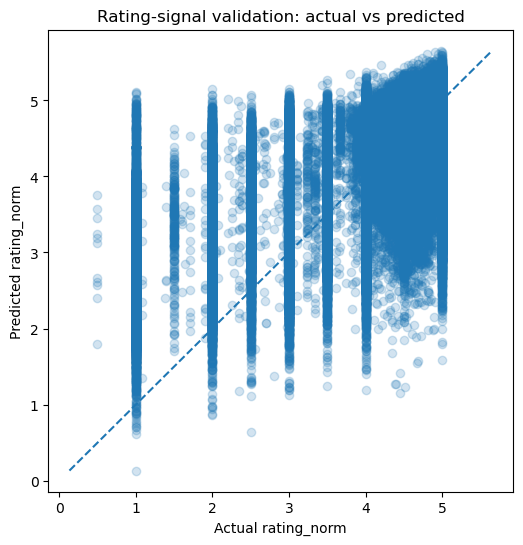

In [69]:
rating_regression_diagnostics_df = pd.DataFrame()

if 'reg_test_df' in globals() and 'reg_pred' in globals() and len(reg_test_df) > 0:
    actual_rating = reg_test_df["rating_norm"].reset_index(drop=True)
    predicted_rating = pd.Series(reg_pred, index=actual_rating.index)
    residuals = predicted_rating - actual_rating

    rating_regression_diagnostics_df = pd.DataFrame([{
        "mae": mean_absolute_error(actual_rating, predicted_rating),
        "rmse": np.sqrt(mean_squared_error(actual_rating, predicted_rating)),
        "mean_residual": residuals.mean(),
        "median_abs_residual": residuals.abs().median(),
        "n_test": len(actual_rating)
    }])

    display(rating_regression_diagnostics_df)

    plt.figure(figsize=(6, 6))
    plt.scatter(actual_rating, predicted_rating, alpha=0.20)
    min_val = float(min(actual_rating.min(), predicted_rating.min()))
    max_val = float(max(actual_rating.max(), predicted_rating.max()))
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("Actual rating_norm")
    plt.ylabel("Predicted rating_norm")
    plt.title("Rating-signal validation: actual vs predicted")
    plt.show()
else:
    print("Rating regression diagnostics skipped because regression outputs were not available.")


## Interpretation note for the Airbnb template-comment robustness check

Template-like Airbnb comments were treated as a robustness issue rather than as automatic noise.

The main benchmark keeps these rows visible for audit purposes because repeated or formulaic comments are not necessarily invalid by default. This follow-up check tests whether removing them materially changes leakage risk or the downstream baseline.

Under the final notebook logic, template-style comment removal is therefore not treated as a mandatory core cleaning rule. Instead, it functions as a sensitivity check showing that the main analytical conclusions do not depend entirely on deleting these rows.

In [70]:
v83_df = model_df.copy()
v83_df["normalised_text_v83"] = v83_df["review_text"].map(normalise_text_for_dup)

airbnb_mask_v83 = v83_df["platform"].astype(str).str.lower().eq("airbnb")
airbnb_dup_counts_v83 = (
    v83_df.loc[airbnb_mask_v83, "normalised_text_v83"]
    .value_counts(dropna=False)
    .to_dict()
)

v83_df["dup_count_airbnb_v83"] = v83_df["normalised_text_v83"].map(airbnb_dup_counts_v83).fillna(0).astype(int)
v83_df["airbnb_template_flag_v83"] = (
    airbnb_mask_v83 &
    (v83_df["normalised_text_v83"] != "") &
    (v83_df["dup_count_airbnb_v83"] >= 3)
).astype(int)

airbnb_removed_templates_v83 = v83_df[v83_df["airbnb_template_flag_v83"] == 1].copy()
model_df_dedup_v83 = v83_df[v83_df["airbnb_template_flag_v83"] == 0].copy()

template_removal_summary_v83 = pd.DataFrame([{
    "original_rows": len(v83_df),
    "dedup_rows": len(model_df_dedup_v83),
    "removed_rows": len(airbnb_removed_templates_v83),
    "removed_share": len(airbnb_removed_templates_v83) / max(len(v83_df), 1)
}])

display(template_removal_summary_v83)

if model_df_dedup_v83["entity_id"].notna().sum() > 0 and v83_df["entity_id"].notna().sum() > 0:
    orig_train_v83, orig_test_v83 = strict_entity_split(v83_df[v83_df["entity_id"].notna()].copy(), entity_col="entity_id", test_size=0.20, random_state=42)
    dedup_train_v83, dedup_test_v83 = strict_entity_split(model_df_dedup_v83[model_df_dedup_v83["entity_id"].notna()].copy(), entity_col="entity_id", test_size=0.20, random_state=42)

    leakage_compare_v83 = pd.DataFrame([
        {"version": "original", **compute_overlap_summary(orig_train_v83, orig_test_v83, text_col="review_text", entity_col="entity_id", split_type="entity_id_strict")},
        {"version": "after_airbnb_template_removal", **compute_overlap_summary(dedup_train_v83, dedup_test_v83, text_col="review_text", entity_col="entity_id", split_type="entity_id_strict")},
    ])
else:
    leakage_compare_v83 = pd.DataFrame()

display(leakage_compare_v83)

def run_simple_baseline_v83(df, label_col="high_rating"):
    tmp = df.copy()
    tmp = tmp[tmp["review_text"].fillna("").astype(str).str.strip() != ""].copy()
    tmp = tmp[tmp["entity_id"].notna()].copy()

    if tmp.empty or tmp[label_col].nunique() < 2 or tmp["entity_id"].nunique() < 2:
        return {
            "split_type": "entity_id_strict",
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1_binary": np.nan,
            "n_train": 0,
            "n_test": 0,
            "n_train_entities": 0,
            "n_test_entities": 0,
        }

    split_train_df, split_test_df = strict_entity_split(tmp, entity_col="entity_id", test_size=0.20, random_state=42)

    X_train_tmp = split_train_df["review_text"]
    X_test_tmp = split_test_df["review_text"]
    y_train_tmp = split_train_df[label_col]
    y_test_tmp = split_test_df[label_col]

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=3)),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ])
    pipe.fit(X_train_tmp, y_train_tmp)
    pred_tmp = pipe.predict(X_test_tmp)

    return {
        "split_type": "entity_id_strict",
        "accuracy": accuracy_score(y_test_tmp, pred_tmp),
        "precision": precision_score(y_test_tmp, pred_tmp, zero_division=0),
        "recall": recall_score(y_test_tmp, pred_tmp, zero_division=0),
        "f1_binary": f1_score(y_test_tmp, pred_tmp, average="binary", zero_division=0),
        "n_train": len(X_train_tmp),
        "n_test": len(X_test_tmp),
        "n_train_entities": split_train_df["entity_id"].nunique(),
        "n_test_entities": split_test_df["entity_id"].nunique(),
    }

baseline_robustness_compare_v83 = pd.DataFrame([
    {"version": "original", **run_simple_baseline_v83(v83_df)},
    {"version": "after_airbnb_template_removal", **run_simple_baseline_v83(model_df_dedup_v83)},
])

display(baseline_robustness_compare_v83)

,original_rows,dedup_rows,removed_rows,removed_share
0,4094950,4024220,70730,0.017272


,version,split_type,entity_overlap_count,exact_text_overlap_count,n_train_rows,n_test_rows,n_train_entities,n_test_entities
0,original,entity_id_strict,0,4925,3293822,801128,63244,15812
1,after_airbnb_template_removal,entity_id_strict,0,2177,3212253,811967,63061,15766


,version,split_type,accuracy,precision,recall,f1_binary,n_train,n_test,n_train_entities,n_test_entities
0,original,entity_id_strict,0.900756,0.918190,0.97168,0.944178,3293822,801128,63244,15812
1,after_airbnb_template_removal,entity_id_strict,0.898527,0.917064,0.97010,0.942837,3212253,811967,63061,15766


## Section 25A2. Benchmark Gap Analysis for aggregated platform indicators

This section is **not a regression task**.  
It compares platform-level summary indicators against a simple ideal benchmark profile and asks:

> which platform is closer to the desired benchmark pattern?

This is more appropriate than using regression language for aggregated platform-level tables.
- lower `mean_gap_to_ideal` means the platform is closer to the selected benchmark profile.


In [71]:
def _normalise_gap_positive(value, target=1.0):
    if pd.isna(value) or pd.isna(target) or target <= 0:
        return np.nan
    score = np.clip(value / target, 0, 1)
    return 1 - score

def _normalise_gap_negative(value, scale=1.0):
    if pd.isna(value) or pd.isna(scale) or scale <= 0:
        return np.nan
    penalty = np.clip(value / scale, 0, 1)
    return penalty

benchmark_gap_rows = []

benchmark_gap_specs = []

if "ranking_metrics_df" in globals() and isinstance(ranking_metrics_df, pd.DataFrame) and len(ranking_metrics_df) > 0:
    benchmark_gap_specs.append({
        "df": ranking_metrics_df.copy(),
        "platform_col": "platform",
        "table_name": "ranking_proxy",
        "positive_targets": {
            "hits_at_10": 10.0,
            "precision_at_10": 1.0,
            "recall_at_10": 1.0,
            "pr_auc_proxy": 1.0,
        },
        "negative_scales": {
            "mae_proxy": 1.0,
            "rmse_proxy": 1.0,
        }
    })

if "recommendation_metrics_df" in globals() and isinstance(recommendation_metrics_df, pd.DataFrame) and len(recommendation_metrics_df) > 0:
    benchmark_gap_specs.append({
        "df": recommendation_metrics_df.copy(),
        "platform_col": "source_platform" if "source_platform" in recommendation_metrics_df.columns else "platform",
        "table_name": "recommendation_proxy",
        "positive_targets": {
            "mean_similarity": 1.0,
            "mean_good_match_rate": 1.0,
        },
        "negative_scales": {}
    })

if "trust_metrics_df" in globals() and isinstance(trust_metrics_df, pd.DataFrame) and len(trust_metrics_df) > 0:
    benchmark_gap_specs.append({
        "df": trust_metrics_df.copy(),
        "platform_col": "platform",
        "table_name": "trust_safety_proxy",
        "positive_targets": {},
        "negative_scales": {
            "flagged_rate": 1.0,
            "duplicate_rate": 1.0,
            "very_short_rate": 1.0,
            "extreme_positive_rate": 1.0,
            "extreme_negative_rate": 1.0,
        }
    })

for spec in benchmark_gap_specs:
    df_gap = spec["df"].copy()
    if spec["platform_col"] not in df_gap.columns:
        continue

    for _, row in df_gap.iterrows():
        platform_value = row[spec["platform_col"]]
        per_metric_gaps = {}

        for metric, target in spec["positive_targets"].items():
            if metric in df_gap.columns:
                per_metric_gaps[f"gap_{metric}"] = _normalise_gap_positive(row[metric], target)

        for metric, scale in spec["negative_scales"].items():
            if metric in df_gap.columns:
                per_metric_gaps[f"gap_{metric}"] = _normalise_gap_negative(row[metric], scale)

        if len(per_metric_gaps) == 0:
            continue

        benchmark_gap_rows.append({
            "table_name": spec["table_name"],
            "platform": platform_value,
            **per_metric_gaps,
            "mean_gap_to_ideal": np.nanmean(list(per_metric_gaps.values()))
        })

benchmark_gap_df = pd.DataFrame(benchmark_gap_rows)

if len(benchmark_gap_df) > 0:
    benchmark_gap_summary_df = (
        benchmark_gap_df.groupby("platform", as_index=False)["mean_gap_to_ideal"]
        .mean()
        .sort_values("mean_gap_to_ideal", ascending=True)
        .reset_index(drop=True)
    )

    print("Benchmark-gap detail by table:")
    display(benchmark_gap_df.sort_values(["table_name", "mean_gap_to_ideal"]))

    print("Average platform gap to ideal (lower is better):")
    display(benchmark_gap_summary_df)
else:
    benchmark_gap_summary_df = pd.DataFrame(columns=["platform", "mean_gap_to_ideal"])
    print("Benchmark gap analysis skipped because no suitable summary tables were available.")


Benchmark-gap detail by table:


,table_name,platform,gap_mean_similarity,gap_mean_good_match_rate,mean_gap_to_ideal,gap_flagged_rate,gap_duplicate_rate,gap_very_short_rate,gap_extreme_positive_rate,gap_extreme_negative_rate
0,recommendation_proxy,airbnb,0.439938,0.072957,0.256447,NaN,NaN,NaN,NaN,NaN
1,recommendation_proxy,booking,0.405530,0.180996,0.293263,NaN,NaN,NaN,NaN,NaN
2,recommendation_proxy,tripadvisor,0.225862,0.367164,0.296513,NaN,NaN,NaN,NaN,NaN
3,trust_safety_proxy,airbnb,NaN,NaN,0.024852,0.014891,0.013825,0.067308,0.027521,0.000718
5,trust_safety_proxy,tripadvisor,NaN,NaN,0.080866,0.002777,0.002156,0.003782,0.341364,0.054250
4,trust_safety_proxy,booking,NaN,NaN,0.082456,0.004541,0.001259,0.008374,0.398067,0.000039


Average platform gap to ideal (lower is better):


,platform,mean_gap_to_ideal
0,airbnb,0.140650
1,booking,0.187859
2,tripadvisor,0.188689


## Conclusion
Overall, the results suggest that the integrated accommodation review dataset is sufficient to support basic within-platform machine-learning tasks, as simple text-based baselines already capture meaningful predictive patterns. However, cross-platform transfer remains uneven across platform pairs, indicating that the main limitation lies not in model complexity alone, but in inconsistencies across platforms in rating behaviour, schema structure, metadata granularity, and review style.

## Recommendation 
The findings suggest that future improvement should prioritize data standardization rather than immediately adopting more sophisticated models. Key priorities include improving cross-platform schema alignment, strengthening location and entity metadata consistency, preserving raw-data auditability, and developing more reliable task-specific proxy labels. A simple regression-style rating-signal validation may still be retained as a **secondary recommendation-oriented extension**, because it helps demonstrate whether the cleaned dataset preserves a basic continuous prediction signal; however, it should not displace the main benchmark story.


## Section 26. Curated report and appendix exports

In [72]:
if EXPORT_CURATED_FINAL_TABLES:
    export_manifest_rows = []

    def export_curated(df, folder, filename, purpose, section, show_head=False):
        if df is None or not isinstance(df, pd.DataFrame) or df.empty:
            return
        out_path = folder / filename
        out_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(out_path, index=False)
        export_manifest_rows.append({
            "file_name": filename,
            "folder": str(folder),
            "section": section,
            "purpose": purpose
        })
        if show_head:
            display(df.head(10))

    export_curated(summary_core, REPORT_DIR, "platform_eda_summary.csv", "Core platform EDA summary", "Report")
    export_curated(rating_anomaly_summary, REPORT_DIR, "anomaly_audit_summary.csv", "Anomaly bridge from raw-data audit to suspicious-review checks", "Report")
    export_curated(ranking_metrics_df, REPORT_DIR, "ranking_proxy_results.csv", "Review-based ranking proxy results", "Report")
    export_curated(recommendation_metrics_df, REPORT_DIR, "recommendation_proxy_results.csv", "Recommendation proxy summary", "Report")
    export_curated(trust_metrics_df, REPORT_DIR, "trust_safety_platform_summary.csv", "Trust & Safety platform summary", "Report")
    export_curated(transfer_results_df, REPORT_DIR, "cross_platform_transfer.csv", "Cross-platform transfer / generalization results", "Report")

    if "addi_compare_df" in globals() and isinstance(addi_compare_df, pd.DataFrame) and not addi_compare_df.empty:
        export_curated(addi_compare_df, REPORT_DIR, "addi_dimension_compare.csv", "Before-vs-after ADDI dimension comparison", "Report")
        addi_score_compare_v86 = pd.DataFrame([{
            "before_addi_score": before_addi_score,
            "after_addi_score": after_addi_score,
            "absolute_change": after_addi_score - before_addi_score,
            "before_interpretation": interpret_addi(before_addi_score),
            "after_interpretation": interpret_addi(after_addi_score),
        }])
        export_curated(addi_score_compare_v86, REPORT_DIR, "addi_score_compare.csv", "Before-vs-after ADDI overall score comparison", "Report")
    else:
        export_curated(addi_dim_df, REPORT_DIR, "addi_dimension_scores.csv", "Single ADDI dimension scores", "Report")
        export_curated(report_addi_summary, REPORT_DIR, "addi_score_summary.csv", "Single ADDI summary", "Report")

    export_curated(raw_source_overview_df, APPENDIX_DIR, "raw_source_overview.csv", "Raw-source introduction and use/exclude decisions", "Appendix")
    export_curated(drop_summary_df, APPENDIX_DIR, "retained_sample_summary.csv", "Wide row-retention summary", "Appendix")
    export_curated(leakage_check_df, APPENDIX_DIR, "leakage_check.csv", "Entity-strict leakage check for text extension", "Appendix")
    export_curated(duplicate_entity_platform_summary, APPENDIX_DIR, "duplicate_entity_summary.csv", "Duplicate-rate summary by platform", "Appendix")
    if "benchmark_gap_summary_df" in globals():
        export_curated(benchmark_gap_summary_df, APPENDIX_DIR, "benchmark_gap_summary.csv", "Benchmark-gap summary for aggregated platform indicators", "Appendix")

    if EXPORT_MANIFEST:
        curated_export_manifest_df = pd.DataFrame(export_manifest_rows)
        curated_export_manifest_df.to_csv(EXPORT_DIR / "curated_export_manifest.csv", index=False)
        display(curated_export_manifest_df)
    else:
        export_summary_df = pd.DataFrame(export_manifest_rows)
        display(export_summary_df)
else:
    print("Curated final export is disabled.")


,file_name,folder,section,purpose
0,platform_eda_summary.csv,C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Expor...,Report,Core platform EDA summary
1,anomaly_audit_summary.csv,C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Expor...,Report,Anomaly bridge from raw-data audit to suspicio...
2,ranking_proxy_results.csv,C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Expor...,Report,Review-based ranking proxy results
3,recommendation_proxy_results.csv,C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Expor...,Report,Recommendation proxy summary
4,trust_safety_platform_summary.csv,C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Expor...,Report,Trust & Safety platform summary
5,cross_platform_transfer.csv,C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Expor...,Report,Cross-platform transfer / generalization results
6,addi_dimension_compare.csv,C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Expor...,Report,Before-vs-after ADDI dimension comparison
7,addi_score_compare.csv,C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Expor...,Report,Before-vs-after ADDI overall score comparison
8,raw_source_overview.csv,C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Expor...,Appendix,Raw-source introduction and use/exclude decisions
9,retained_sample_summary.csv,C:\Users\Mo\Desktop\hkk\DataBase\FYP\FYP_Expor...,Appendix,Wide row-retention summary
